# About Dataset
source : https://archive.ics.uci.edu/dataset/45/heart+disease
Only 14 attributes used:
1. #3  (age)       
2. #4  (sex)       
3. #9  (cp)        
4. #10 (trestbps)  
5. #12 (chol)      
6. #16 (fbs)       
7. #19 (restecg)   
8. #32 (thalach)   
9. #38 (exang)     
10. #40 (oldpeak)   
11. #41 (slope)     
12. #44 (ca)        
13. #51 (thal)      
14. #58 (num)       (the predicted attribute)

Complete attribute documentation:
1.     3 age: age in years
2.     4 sex: sex (1 = male; 0 = female)
3.    9 cp: chest pain type
        -- Value 1: typical angina
        -- Value 2: atypical angina
        -- Value 3: non-anginal pain
        -- Value 4: asymptomatic
 4.    10 trestbps: resting blood pressure (in mm Hg on admission to the hospital)
 5.    12 chol: serum cholestoral in mg/dl
 6.   16 fbs: (fasting blood sugar > 120 mg/dl)  (1 = true; 0 = false)
7.   32 thalach: maximum heart rate achieved
8.    38 exang: exercise induced angina (1 = yes; 0 = no)
9.   40 oldpeak = ST depression induced by exercise relative to rest
10.      41 slope: the slope of the peak exercise ST segment
        -- Value 1: upsloping
        -- Value 2: flat
        -- Value 3: downsloping
 11.    44 ca: number of major vessels (0-3) colored by flourosopy
 12.    51 thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
 13.    58 num: diagnosis of heart disease (angiographic disease status)
        -- Value 0: < 50% diameter narrowing
        -- Value 1: > 50% diameter narrowing
        (in any major vessel: attributes 59 through 68 are vessels)

### versi lebih mudah

Kolom    Artinya secara gampang
age=    Umur pasien
sex=    Jenis kelamin
cp=    Tipe nyeri dada (chest pain)
trestbps=    Tekanan darah saat istirahat
chol=    Kadar kolesterol
fbs=    Apakah gula darah puasa >120 mg/dL
restecg=    Hasil ECG saat istirahat
thalach=    Detak jantung maksimum yang tercapai
exang=    Apakah olahraga memicu angina/nyeri dada
oldpeak=    Penurunan segmen ST akibat olahraga dibanding istirahat
slope=    Bentuk/kemiringan segmen ST saat puncak olahraga
ca=    Jumlah pembuluh darah utama yang terlihat melalui fluoroskopi
thal=    Hasil pemeriksaan terkait thalassemia/perfusi jantung
target    Label: ada/tidak penyakit jantung

In [84]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt


In [85]:
data = pd.read_csv("heart_disease_dataset.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [86]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### notes
1. Tidak ada missing value pada semua fitur
2. Pasien paling parah cp nya di Value 3 (non anginal pain)
3. Restecg kemungkinan besar bersifat kategorikal
4. Oldpeak rangenya tidak jauh
5. Slope hanya mencapai Flat saja
6. Ca seharusnya sampai 3 saja, tapi max ada di 4
7. Value thal di verifikasi ulang nanti

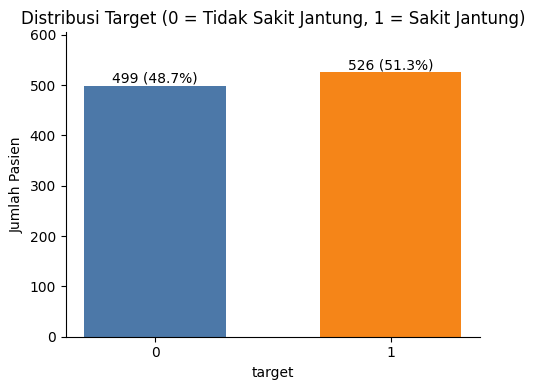

target
1    526
0    499
Name: count, dtype: int64
target
1    0.5132
0    0.4868
Name: proportion, dtype: float64


In [87]:
counts = data['target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(counts.index.astype(str), counts.values,
              color=['#4C78A8', '#F58518'], width=0.6)

# label jumlah + persentase di atas tiap batang
total = counts.sum()
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v,
            f'{v} ({v/total:.1%})', ha='center', va='bottom', fontsize=10)

ax.set_title('Distribusi Target (0 = Tidak Sakit Jantung, 1 = Sakit Jantung)')
ax.set_xlabel('target')
ax.set_ylabel('Jumlah Pasien')
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(data['target'].value_counts())
print(data['target'].value_counts(normalize=True).round(4))


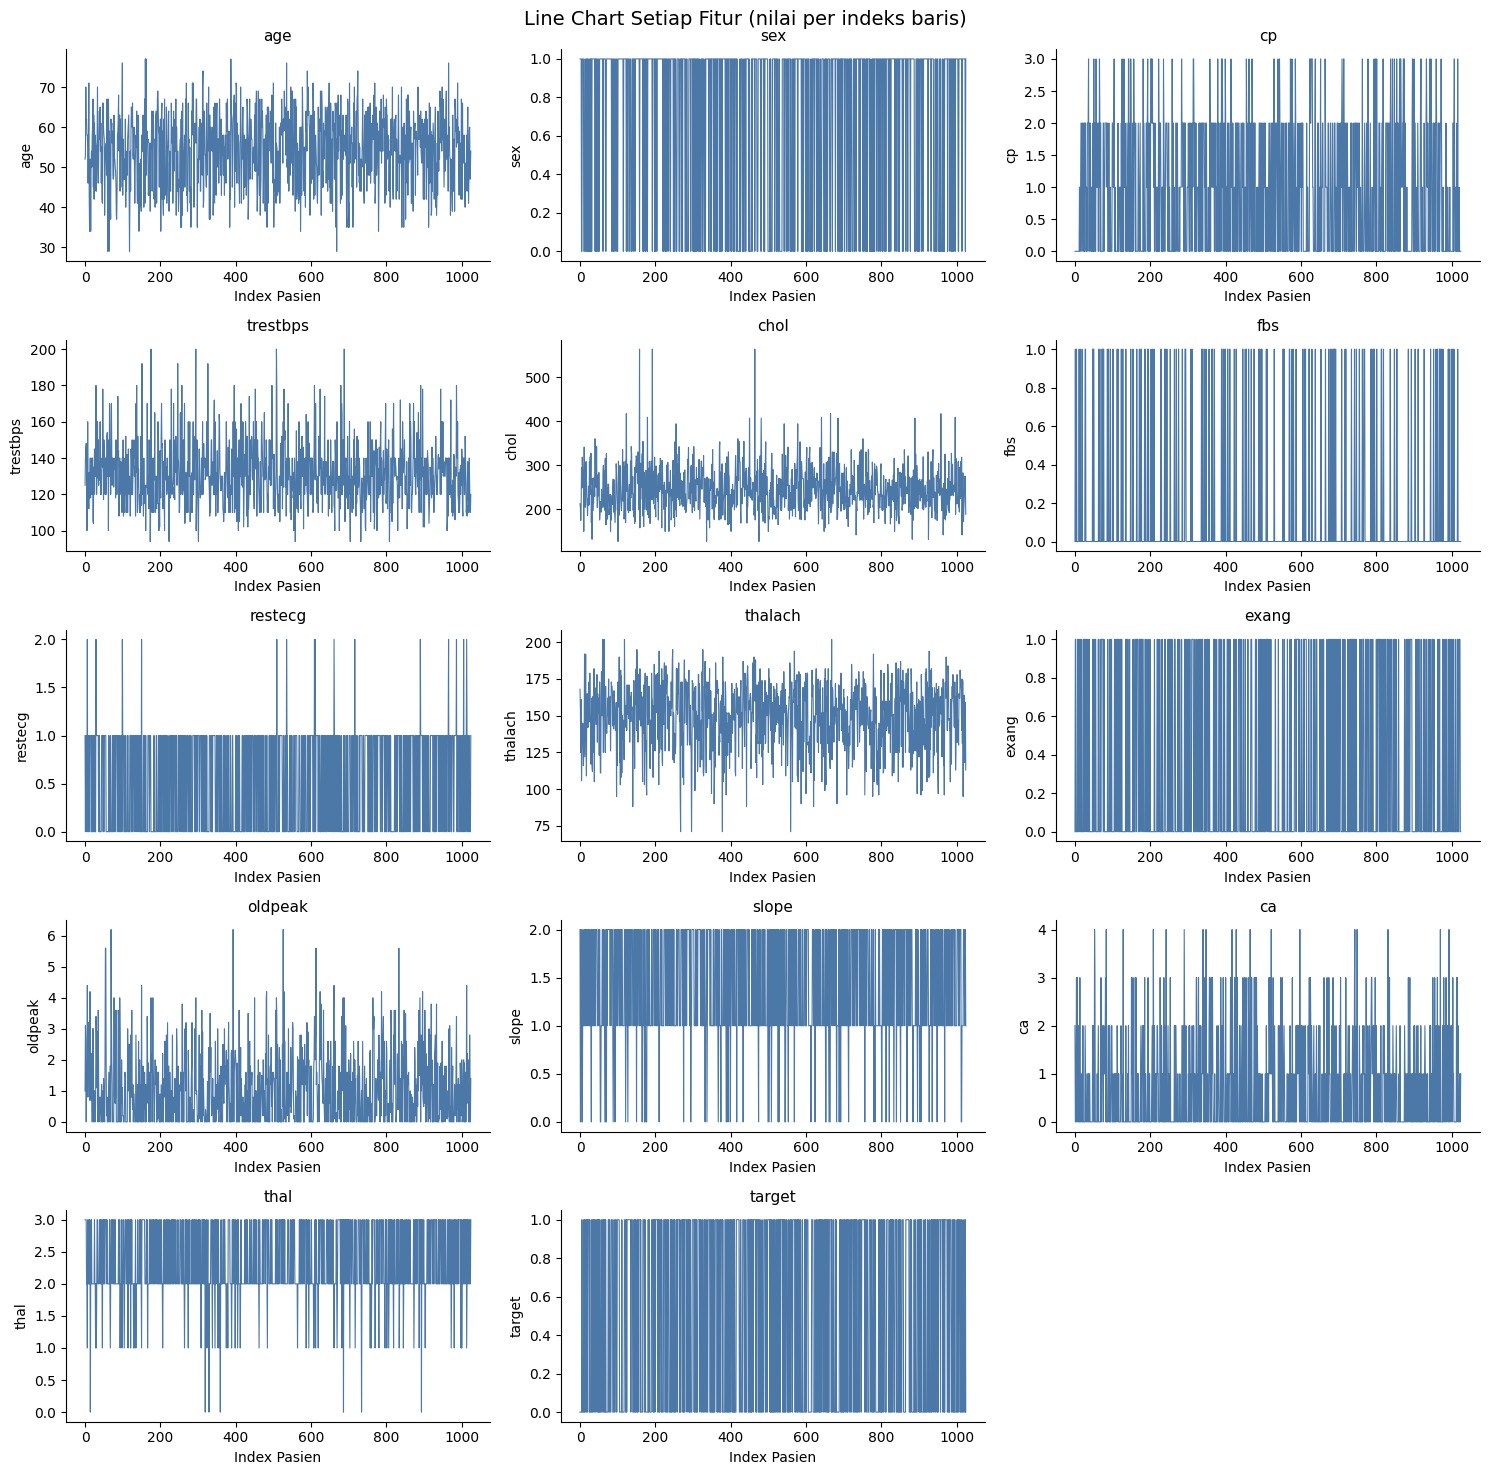

In [88]:
# guard: pastikan `data` tetap DataFrame (pernah tertimpa jadi Series -> KeyError 'target')
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

cols  = data.select_dtypes(include=np.number).columns.tolist()   # hanya kolom numerik
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = np.atleast_1d(axes).ravel()        # aman walau grid 1x1 / 1 baris

for ax, col in zip(axes, cols):
    ax.plot(data.index, data[col], color='#4C78A8', linewidth=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Index Pasien')
    ax.set_ylabel(col)
    for sisi in ('top', 'right'):          # kompatibel semua versi matplotlib
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:                        # matikan subplot sisa
    ax.set_visible(False)

fig.suptitle('Line Chart Setiap Fitur (nilai per indeks baris)', fontsize=14)
plt.tight_layout()
plt.show()

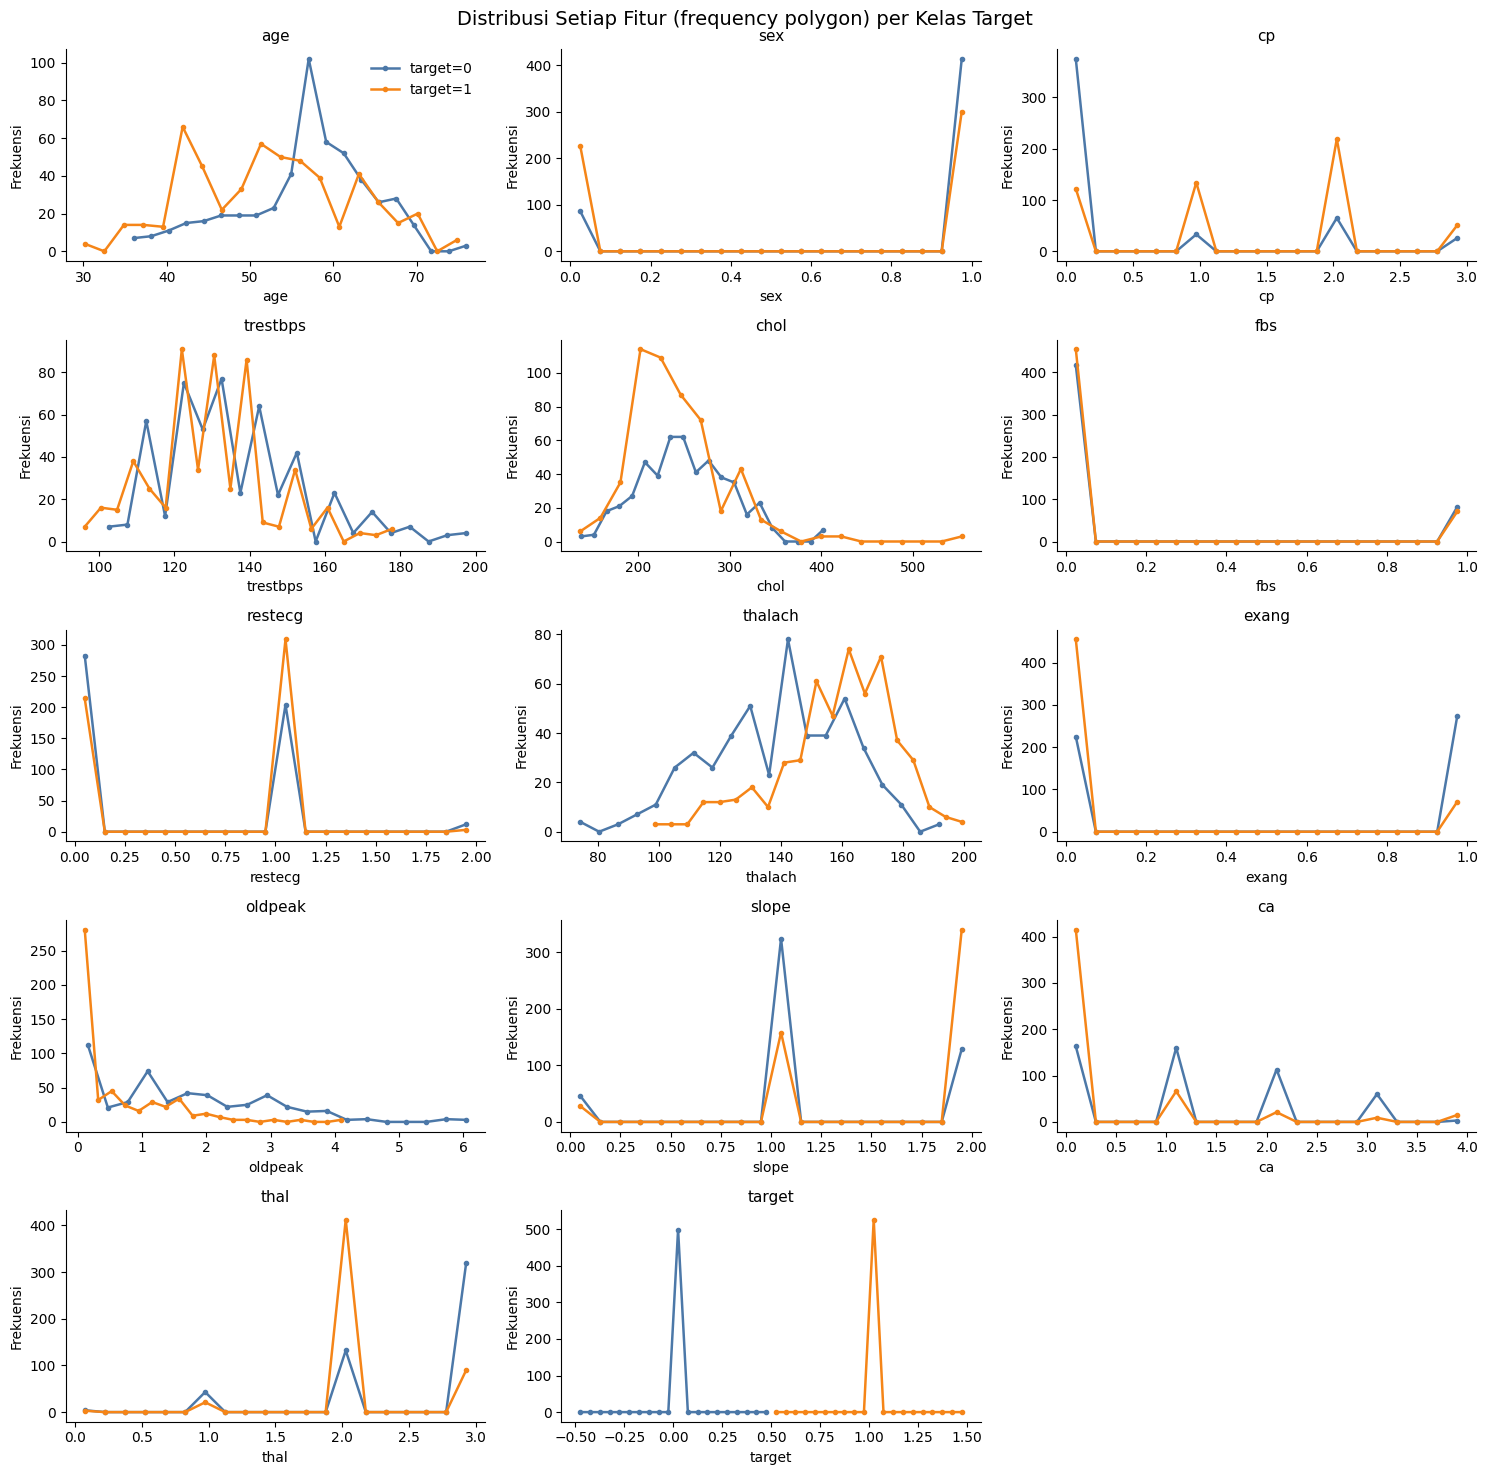

In [89]:
# guard: pastikan `data` tetap DataFrame (pernah tertimpa jadi Series -> KeyError 'target')
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

cols  = data.select_dtypes(include=np.number).columns.tolist()
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data.loc[data['target'] == t, col].dropna()
        if subset.empty:
            continue
        freq, edges = np.histogram(subset, bins=20)
        centers = (edges[:-1] + edges[1:]) / 2
        ax.plot(centers, freq, color=warna, linewidth=1.8,
                marker='o', markersize=3, label=f'target={t}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False)
fig.suptitle('Distribusi Setiap Fitur (frequency polygon) per Kelas Target', fontsize=14)
plt.tight_layout()
plt.show()

### notes
1. Yang kategorikal adalah sex, cp, fbs, exang, slope, ca, thal, target

## Scatter Plot Setiap Fitur

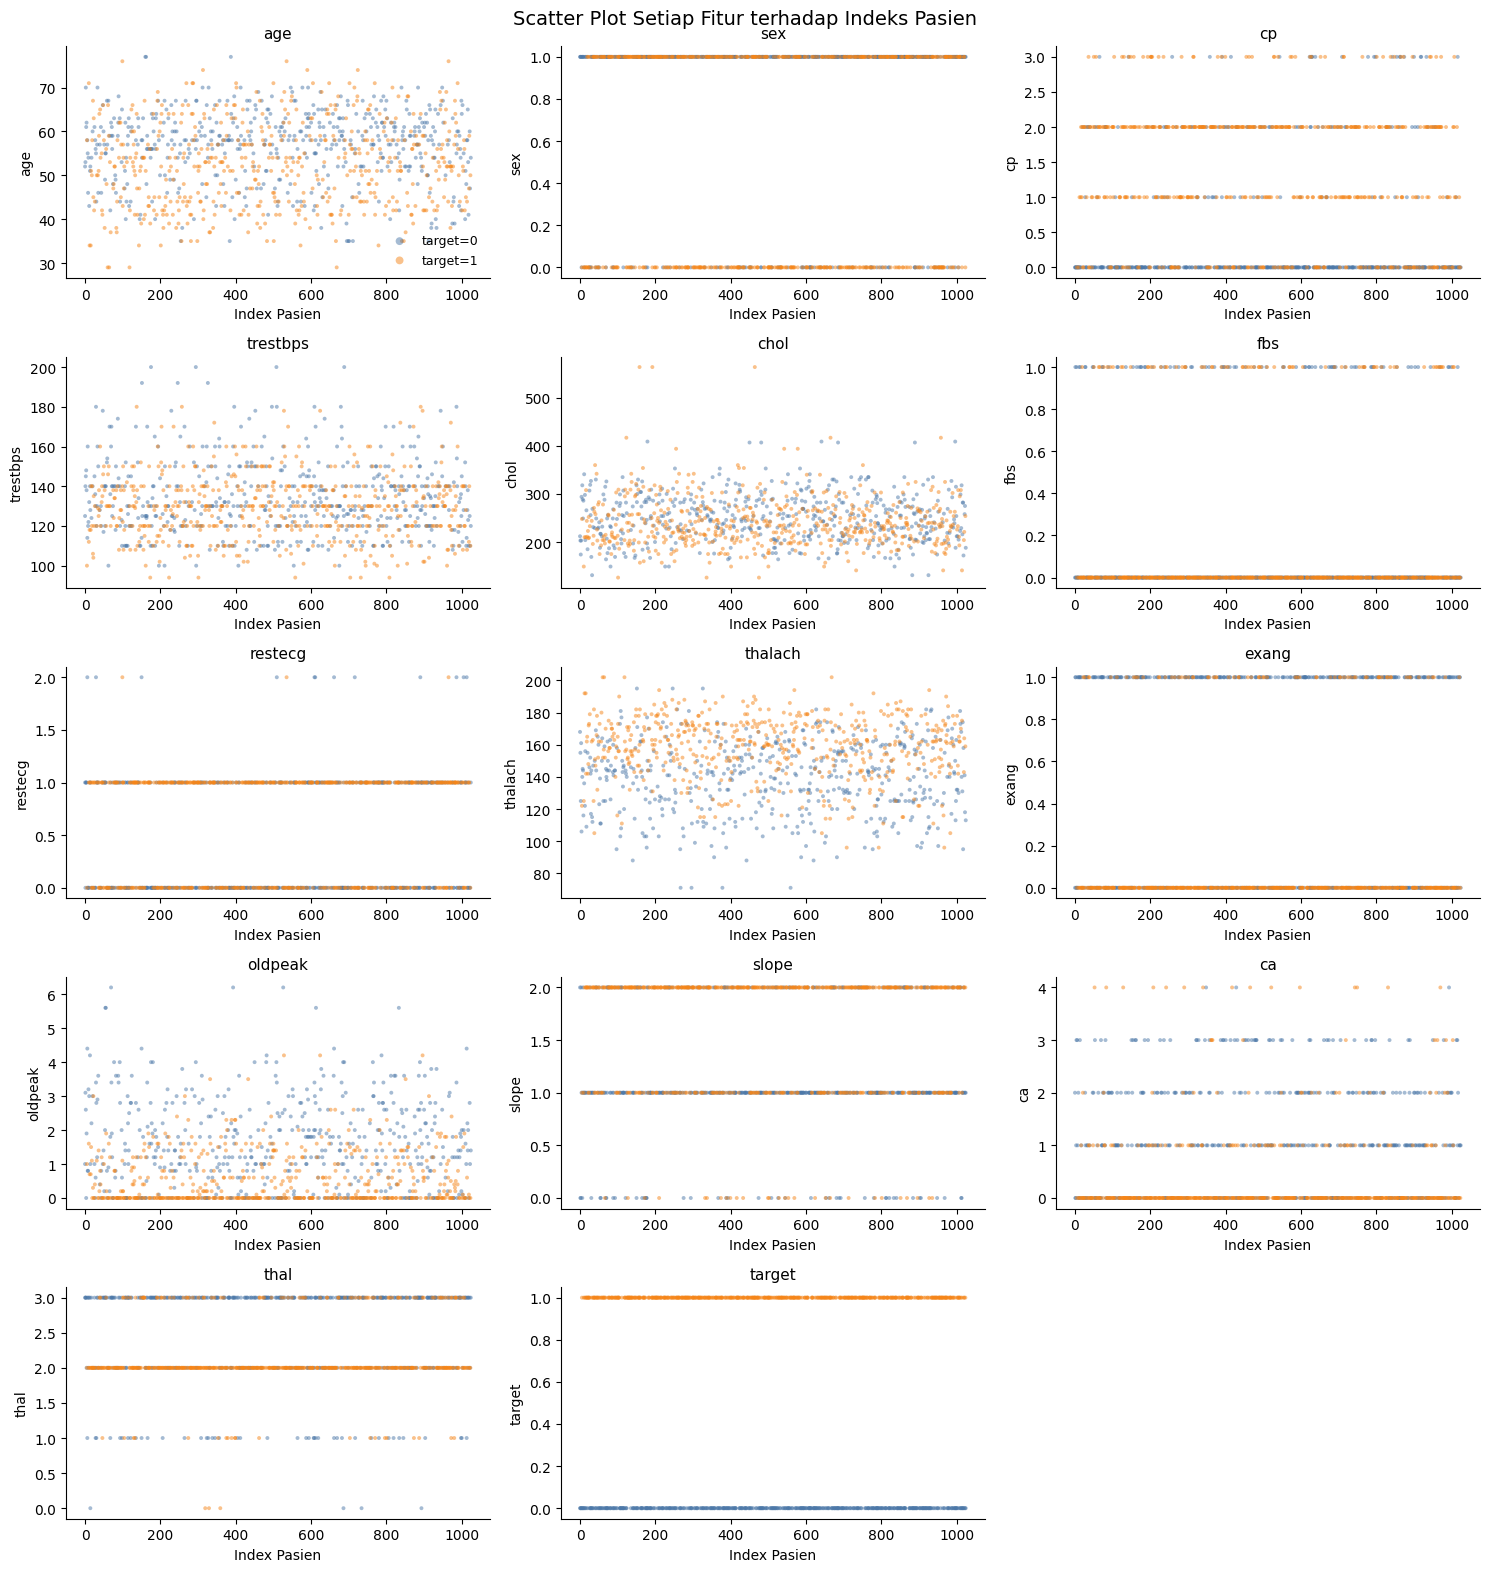

In [90]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# scatter tiap fitur terhadap indeks pasien, diwarnai kelas target
cols  = data.select_dtypes(include=np.number).columns.tolist()
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data[data['target'] == t]
        ax.scatter(subset.index, subset[col], s=8, alpha=0.5,
                   color=warna, edgecolors='none', label=f'target={t}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Index Pasien')
    ax.set_ylabel(col)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False, markerscale=2, fontsize=9)
fig.suptitle('Scatter Plot Setiap Fitur terhadap Indeks Pasien', fontsize=14)
plt.tight_layout()
plt.show()

1. thal = 2 menghasilkan target 1 yang cukup banyak
2. fbs = di value 0 banyak target 1
3. slope = value 2 banyak target 1
4. exang = value 0 banyak trget 1
5. ca = value 0 banyak target 1
6. restecg ambigu untuk diliat manual

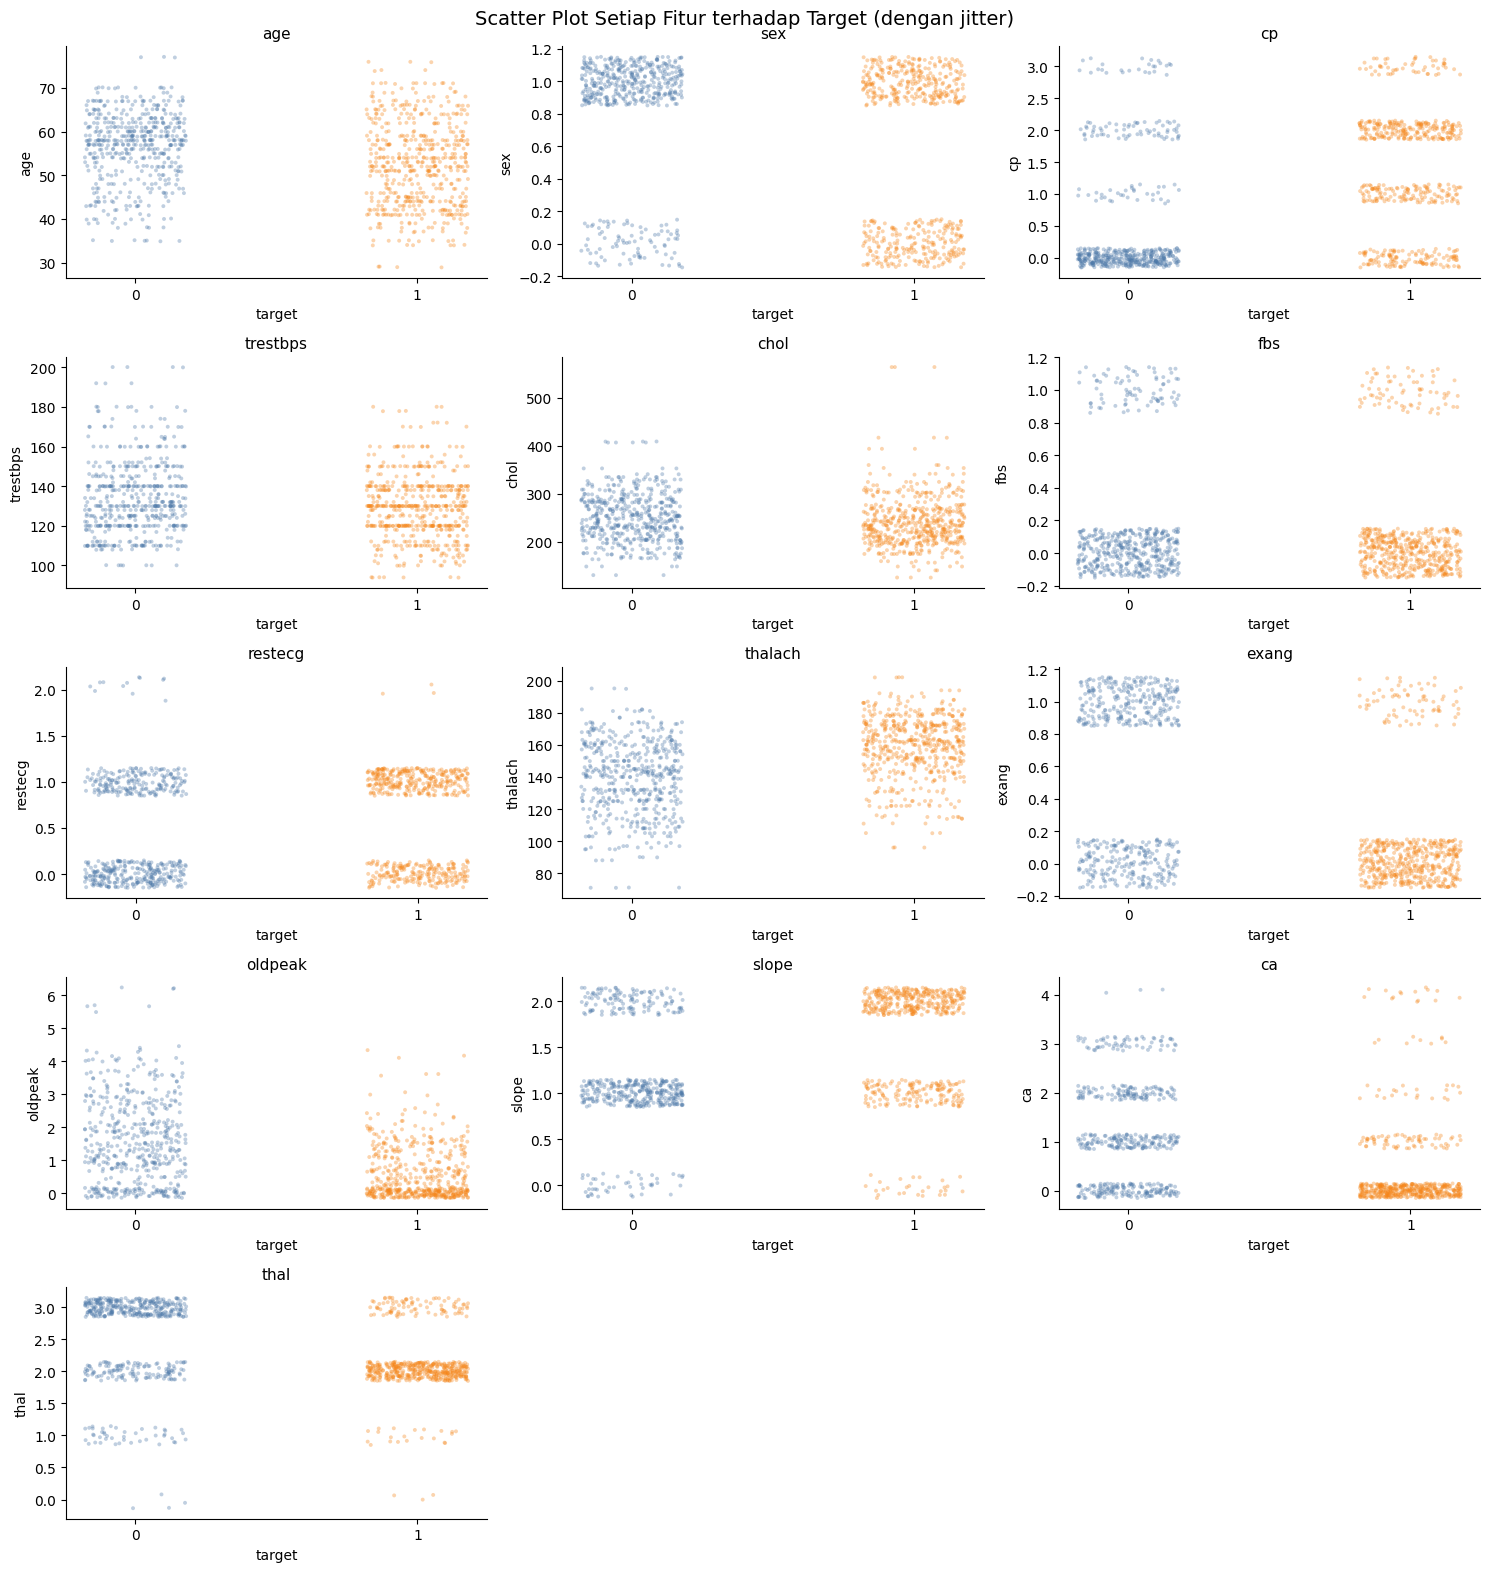

In [91]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# scatter tiap fitur terhadap target, pakai jitter supaya titik tidak saling menimpa
cols  = [c for c in data.select_dtypes(include=np.number).columns if c != 'target']
n     = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

rng = np.random.default_rng(42)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data[data['target'] == t]
        x = t + rng.uniform(-0.18, 0.18, size=len(subset))
        y = subset[col] + rng.uniform(-0.15, 0.15, size=len(subset))
        ax.scatter(x, y, s=8, alpha=0.35, color=warna, edgecolors='none')
    ax.set_xticks([0, 1])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('target')
    ax.set_ylabel(col)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Scatter Plot Setiap Fitur terhadap Target (dengan jitter)', fontsize=14)
plt.tight_layout()
plt.show()

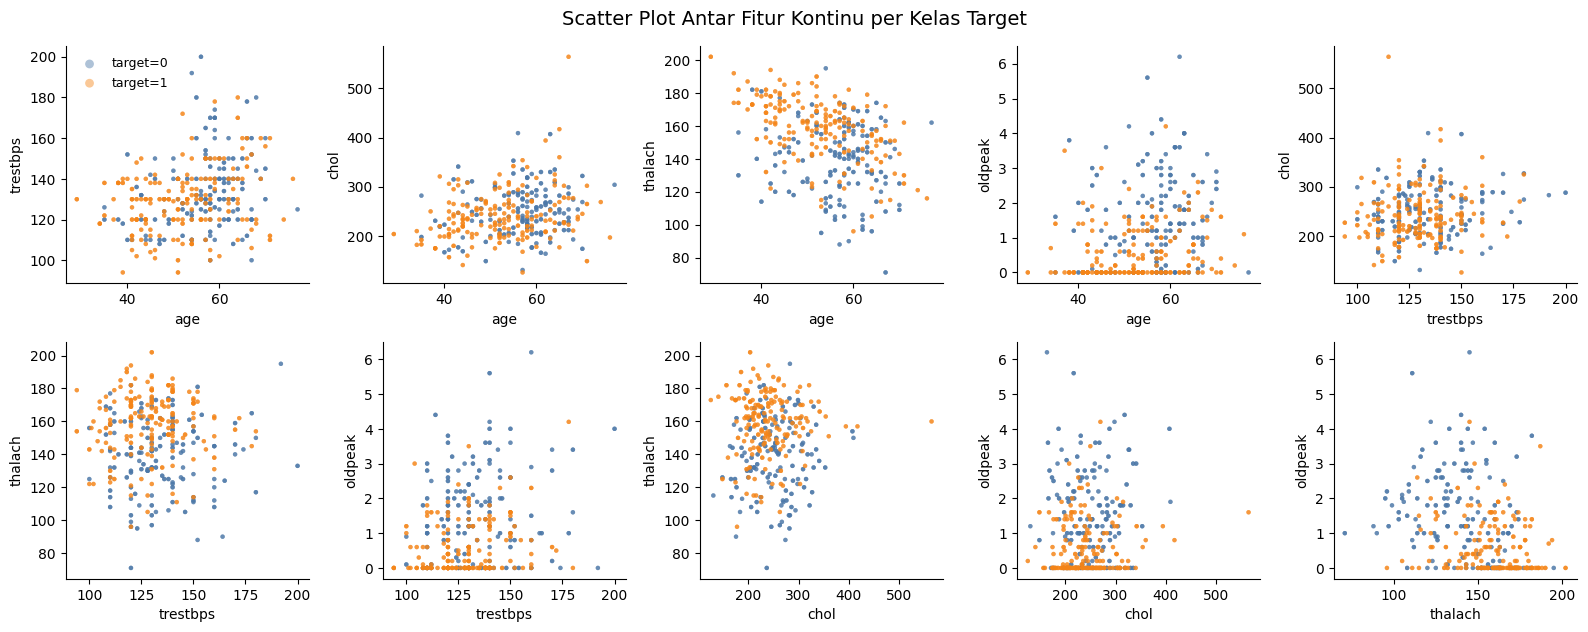

In [92]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# scatter antar pasangan fitur kontinu, diwarnai kelas target
kontinu = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

pasangan = [(a, b) for i, a in enumerate(kontinu) for b in kontinu[i + 1:]]
n     = len(pasangan)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (x_col, y_col) in zip(axes, pasangan):
    for t, warna in zip([0, 1], ['#4C78A8', '#F58518']):
        subset = data[data['target'] == t]
        ax.scatter(subset[x_col], subset[y_col], s=10, alpha=0.45,
                   color=warna, edgecolors='none', label=f'target={t}')
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False, markerscale=2, fontsize=9)
fig.suptitle('Scatter Plot Antar Fitur Kontinu per Kelas Target', fontsize=14)
plt.tight_layout()
plt.show()

### notes scatter
1. Scatter terhadap indeks pasien memperlihatkan sebaran nilai sekaligus memisahkan warna per kelas target - berguna untuk melihat apakah data terurut atau ada pola aneh pada urutan baris
2. Fitur kategorik akan tampak sebagai garis-garis titik horizontal karena nilainya hanya 0-3; itu wajar, bukan error
3. Scatter terhadap target memakai jitter agar titik yang bertumpuk terlihat kepadatannya
4. Scatter antar fitur kontinu paling informatif: cari pemisahan warna, misalnya thalach tinggi lebih banyak di target=1, sedangkan oldpeak tinggi lebih banyak di target=0

## Korelasi Antar Fitur: Pearson vs Spearman

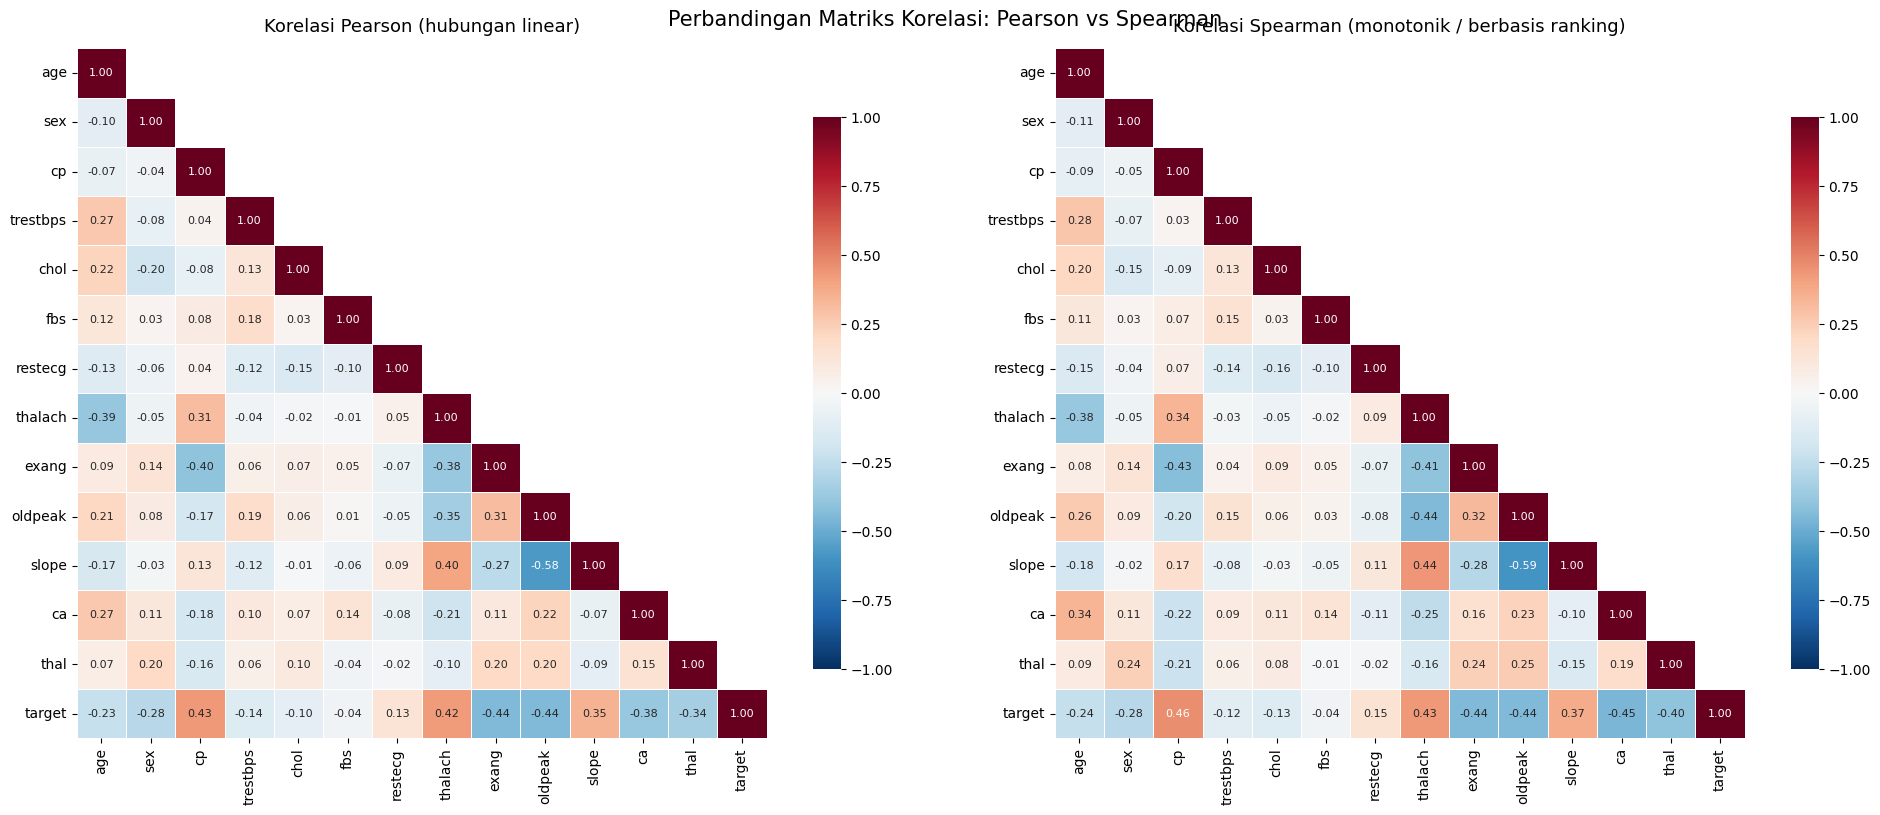

In [93]:
# guard: pastikan `data` tetap DataFrame (pernah tertimpa jadi Series -> KeyError 'target')
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

corr_pearson  = data.corr(method='pearson',  numeric_only=True)
corr_spearman = data.corr(method='spearman', numeric_only=True)

mask = np.triu(np.ones_like(corr_pearson, dtype=bool), k=1)   # sembunyikan segitiga atas

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, corr, judul in zip(axes,
                           [corr_pearson, corr_spearman],
                           ['Pearson (hubungan linear)',
                            'Spearman (monotonik / berbasis ranking)']):
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 8}, ax=ax)
    ax.set_title(f'Korelasi {judul}', fontsize=13, pad=12)

fig.suptitle('Perbandingan Matriks Korelasi: Pearson vs Spearman', fontsize=15)
plt.tight_layout()
plt.show()

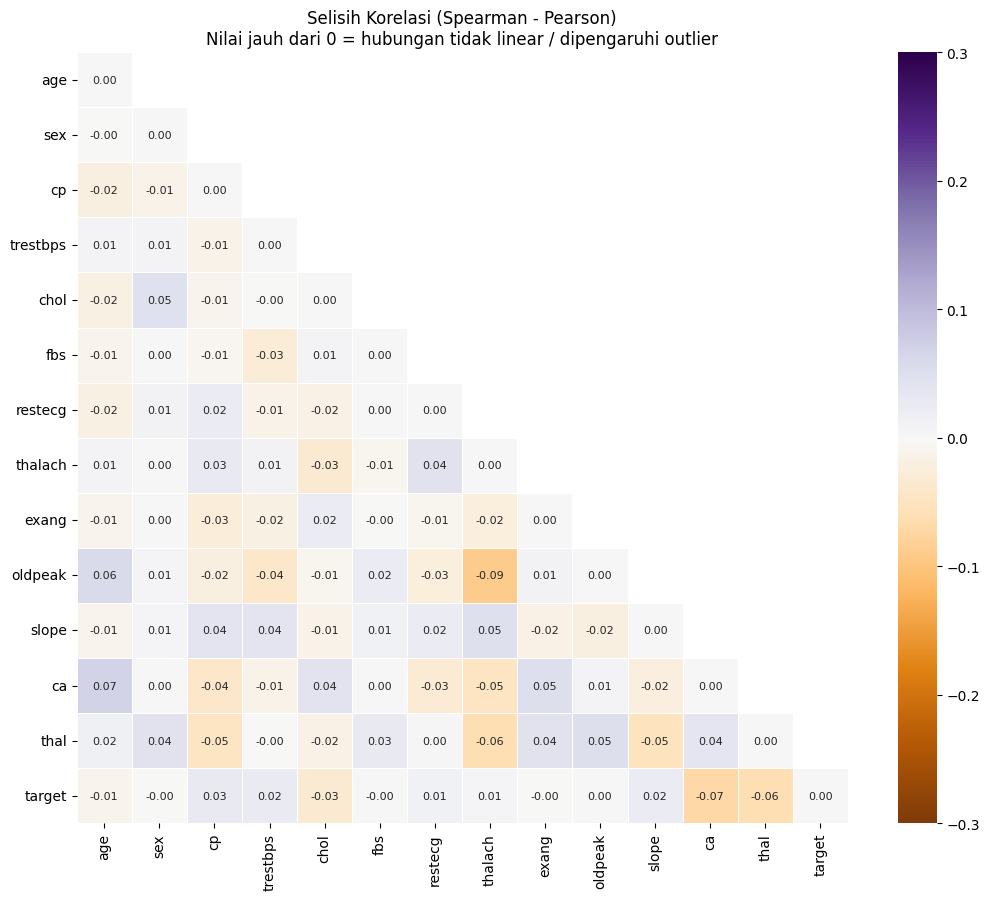

In [94]:
diff = corr_spearman - corr_pearson

plt.figure(figsize=(11, 9))
sns.heatmap(diff, mask=mask, annot=True, fmt='.2f', cmap='PuOr',
            center=0, vmin=-0.3, vmax=0.3, square=True,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Selisih Korelasi (Spearman - Pearson)\n'
          'Nilai jauh dari 0 = hubungan tidak linear / dipengaruhi outlier', fontsize=12)
plt.tight_layout()
plt.show()

In [95]:
# ambil segitiga bawah saja supaya tiap pasangan fitur muncul sekali
tril = np.tril(np.ones(corr_pearson.shape), k=-1).astype(bool)

pairs = corr_pearson.where(tril).stack().rename('pearson').to_frame()
pairs['spearman']    = corr_spearman.where(tril).stack()
pairs['selisih']     = pairs['spearman'] - pairs['pearson']
pairs['abs_selisih'] = pairs['selisih'].abs()

perbandingan = (pairs.sort_values('abs_selisih', ascending=False)
                     .round(3)
                     .reset_index()
                     .rename(columns={'level_0': 'fitur_1', 'level_1': 'fitur_2'}))

print('=== 10 pasangan dengan perbedaan Pearson vs Spearman terbesar ===')
print(perbandingan.head(10).to_string(index=False))

target_corr = pd.DataFrame({
    'pearson':  corr_pearson['target'],
    'spearman': corr_spearman['target'],
}).drop(index='target')
target_corr['selisih'] = target_corr['spearman'] - target_corr['pearson']

print('\n=== Korelasi setiap fitur terhadap target ===')
print(target_corr.round(3)
                 .sort_values('spearman', key=abs, ascending=False)
                 .to_string())

=== 10 pasangan dengan perbedaan Pearson vs Spearman terbesar ===
fitur_1 fitur_2  pearson  spearman  selisih  abs_selisih
oldpeak thalach   -0.350    -0.440   -0.090        0.090
 target      ca   -0.382    -0.453   -0.071        0.071
     ca     age    0.272     0.340    0.068        0.068
 target    thal   -0.338    -0.399   -0.061        0.061
   thal thalach   -0.098    -0.159   -0.061        0.061
oldpeak     age    0.208     0.265    0.056        0.056
   thal   slope   -0.094    -0.146   -0.052        0.052
     ca   exang    0.108     0.159    0.051        0.051
   thal oldpeak    0.203     0.253    0.051        0.051
   thal      cp   -0.163    -0.212   -0.049        0.049

=== Korelasi setiap fitur terhadap target ===
          pearson  spearman  selisih
cp          0.435     0.465    0.030
ca         -0.382    -0.453   -0.071
exang      -0.438    -0.438   -0.000
oldpeak    -0.438    -0.438    0.001
thalach     0.423     0.430    0.007
thal       -0.338    -0.399   -0.061
s

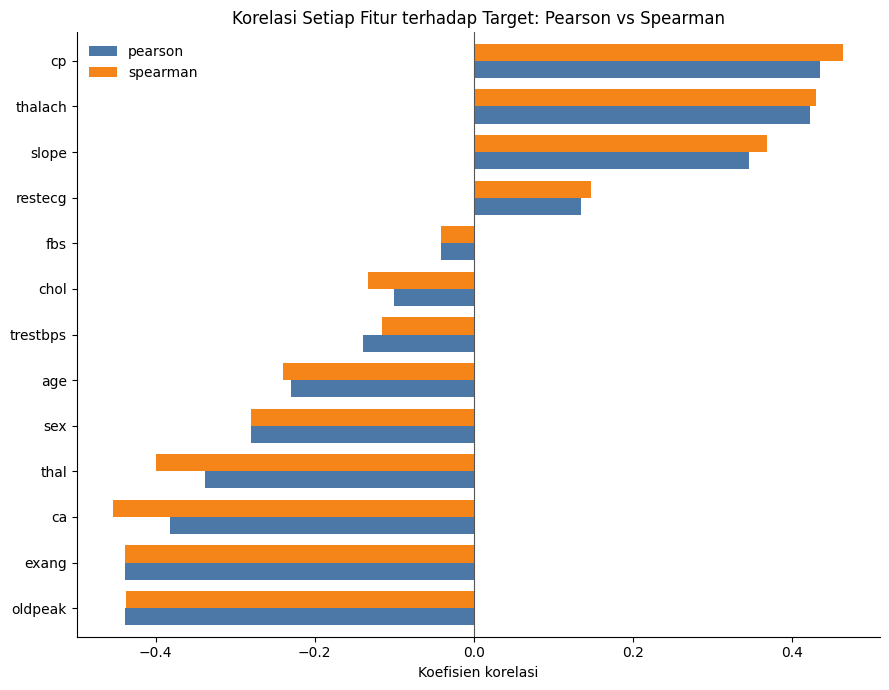

In [96]:
plot_df = target_corr.sort_values('pearson')[['pearson', 'spearman']]

ax = plot_df.plot(kind='barh', figsize=(9, 7),
                  color=['#4C78A8', '#F58518'], width=0.75)
ax.axvline(0, color='#555', linewidth=0.8)
ax.set_title('Korelasi Setiap Fitur terhadap Target: Pearson vs Spearman')
ax.set_xlabel('Koefisien korelasi')
ax.legend(frameon=False)
for sisi in ('top', 'right'):
    ax.spines[sisi].set_visible(False)
plt.tight_layout()
plt.show()

### notes korelasi
1. Pearson mengukur hubungan linear, cocok untuk fitur numerik kontinu (age, trestbps, chol, thalach, oldpeak)
2. Spearman berbasis ranking, lebih tahan outlier dan lebih tepat untuk fitur ordinal (cp, slope, ca, thal)
3. Untuk fitur biner (sex, fbs, exang, target) kedua nilai akan mirip dan setara point-biserial
4. Selisih besar pada heatmap Spearman - Pearson = penanda hubungan non-linear atau pengaruh outlier

## Deteksi Outlier dengan Box Plot

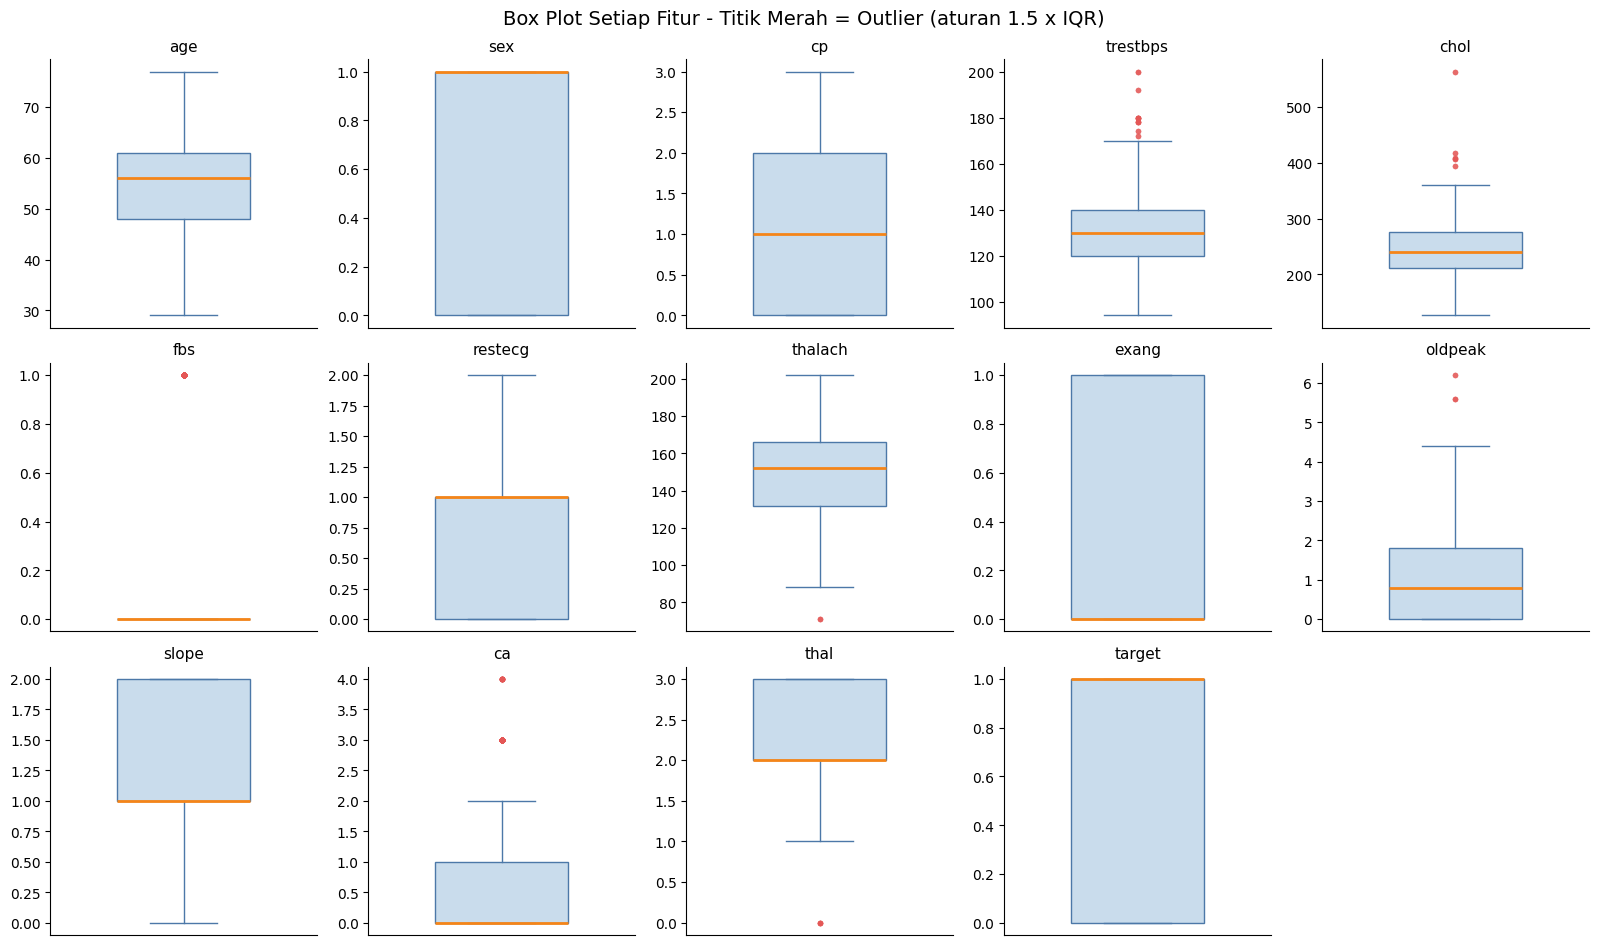

In [97]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

cols  = data.select_dtypes(include=np.number).columns.tolist()
n     = len(cols)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    ax.boxplot(data[col].dropna(), vert=True, widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor='#C9DCEC', edgecolor='#4C78A8'),
               medianprops=dict(color='#F58518', linewidth=2),
               whiskerprops=dict(color='#4C78A8'),
               capprops=dict(color='#4C78A8'),
               flierprops=dict(marker='o', markersize=4,
                               markerfacecolor='#E45756', alpha=0.5,
                               markeredgecolor='none'))
    ax.set_title(col, fontsize=11)
    ax.set_xticks([])
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Box Plot Setiap Fitur - Titik Merah = Outlier (aturan 1.5 x IQR)', fontsize=14)
plt.tight_layout()
plt.show()

In [98]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# hitung outlier tiap fitur pakai aturan Tukey (1.5 x IQR)
ringkasan = []
for col in data.select_dtypes(include=np.number).columns:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = data[(data[col] < low) | (data[col] > high)][col]
    ringkasan.append({
        'fitur': col,
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'batas_bawah': low, 'batas_atas': high,
        'n_outlier': len(out),
        'persen': round(len(out) / len(data) * 100, 2),
        'min_outlier': out.min() if len(out) else np.nan,
        'max_outlier': out.max() if len(out) else np.nan,
    })

outlier_summary = (pd.DataFrame(ringkasan)
                     .set_index('fitur')
                     .round(2)
                     .sort_values('n_outlier', ascending=False))

print('=== Ringkasan Outlier per Fitur (aturan 1.5 x IQR) ===')
print(outlier_summary.to_string())
print(f'\nTotal baris: {len(data)}')

=== Ringkasan Outlier per Fitur (aturan 1.5 x IQR) ===
             Q1     Q3   IQR  batas_bawah  batas_atas  n_outlier  persen  min_outlier  max_outlier
fitur                                                                                             
fbs         0.0    0.0   0.0          0.0         0.0        153   14.93          1.0          1.0
ca          0.0    1.0   1.0         -1.5         2.5         87    8.49          3.0          4.0
trestbps  120.0  140.0  20.0         90.0       170.0         30    2.93        172.0        200.0
chol      211.0  275.0  64.0        115.0       371.0         16    1.56        394.0        564.0
oldpeak     0.0    1.8   1.8         -2.7         4.5          7    0.68          5.6          6.2
thal        2.0    3.0   1.0          0.5         4.5          7    0.68          0.0          0.0
thalach   132.0  166.0  34.0         81.0       217.0          4    0.39         71.0         71.0
age        48.0   61.0  13.0         28.5        80.5 

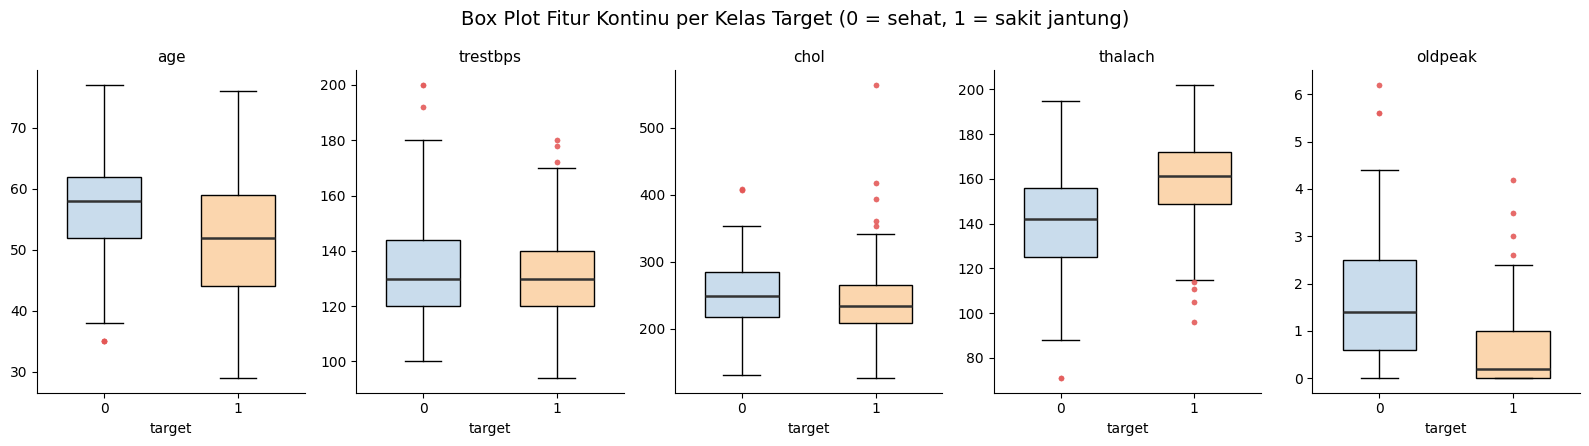

In [99]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# fokus ke fitur numerik kontinu, dipisah per kelas target
kontinu = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(kontinu), figsize=(16, 4.5))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, kontinu):
    kelompok = [data.loc[data['target'] == t, col].dropna() for t in (0, 1)]
    bp = ax.boxplot(kelompok, widths=0.55, patch_artist=True,
                    medianprops=dict(color='#333', linewidth=1.8),
                    flierprops=dict(marker='o', markersize=4,
                                    markerfacecolor='#E45756', alpha=0.5,
                                    markeredgecolor='none'))
    for patch, warna in zip(bp['boxes'], ['#C9DCEC', '#FBD6AE']):
        patch.set_facecolor(warna)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['0', '1'])
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('target')
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

fig.suptitle('Box Plot Fitur Kontinu per Kelas Target (0 = sehat, 1 = sakit jantung)',
             fontsize=14)
plt.tight_layout()
plt.show()

### notes outlier
1. Box plot memakai aturan Tukey: nilai di luar Q1 - 1.5 x IQR atau Q3 + 1.5 x IQR dianggap outlier
2. Fitur kategorik (sex, cp, fbs, restecg, exang, slope, ca, thal, target) tetap ditampilkan untuk kelengkapan, tapi "outlier" di situ hanya berarti kategori yang jarang muncul, bukan nilai ekstrem
3. Outlier pada fitur kontinu (chol, trestbps, oldpeak) adalah yang paling layak dibahas karena berpengaruh ke Pearson - bandingkan dengan heatmap selisih Spearman - Pearson di atas
4. Jangan langsung dibuang: nilai ekstrem pada data medis sering justru kasus yang penting

## Lokasi Baris Outlier: Index Baris Persisnya

Box plot dan line chart di atas hanya memperlihatkan *bahwa* ada outlier.
Bagian ini menjawab *di baris mana* outlier itu berada, memakai aturan yang sama
(Tukey 1.5 x IQR), supaya bisa langsung ditindaklanjuti di tahap preprocessing.

Index baris di sini = `data.index`, yaitu angka yang sama dengan sumbu x
('Index Pasien') pada line chart dan scatter plot sebelumnya.

In [100]:
# guard: pastikan `data` tetap DataFrame
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

# ---- kumpulkan SEMUA baris outlier (aturan Tukey 1.5 x IQR) ----
baris = []
for col in data.select_dtypes(include=np.number).columns:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (data[col] < low) | (data[col] > high)
    for idx in data.index[mask]:
        nilai = data.at[idx, col]
        baris.append({
            'fitur': col,
            'baris': idx,                      # index baris = sumbu x pada line chart
            'nilai': nilai,
            'arah': 'bawah' if nilai < low else 'atas',
            'batas_bawah': low,
            'batas_atas': high,
            'target': data.at[idx, 'target'],
        })

outlier_rows = pd.DataFrame(baris)
KONTINU = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print(f'Total baris data      : {len(data)}')
print(f'Total deteksi outlier : {len(outlier_rows)} (satu baris bisa outlier di >1 fitur)')
print(f'Baris unik terdampak  : {outlier_rows["baris"].nunique()}\n')

print('=== Daftar index baris outlier per fitur ===')
for fitur, grup in outlier_rows.groupby('fitur', sort=False):
    idx_list = sorted(grup['baris'].tolist())
    jenis = 'kontinu' if fitur in KONTINU else 'kategorik (kategori langka, bukan nilai ekstrem)'
    print(f'\n[{fitur}] n={len(idx_list)} | {jenis}')
    print(f'  rentang wajar: {grup["batas_bawah"].iloc[0]:.2f} s/d {grup["batas_atas"].iloc[0]:.2f}')
    print('  index baris  :', ', '.join(map(str, idx_list)))

Total baris data      : 1025
Total deteksi outlier : 304 (satu baris bisa outlier di >1 fitur)
Baris unik terdampak  : 256

=== Daftar index baris outlier per fitur ===

[trestbps] n=30 | kontinu
  rentang wajar: 90.00 s/d 170.00
  index baris  : 29, 47, 87, 137, 151, 175, 229, 246, 257, 294, 326, 343, 396, 436, 452, 496, 508, 509, 528, 609, 624, 636, 679, 688, 837, 891, 896, 944, 971, 986

[chol] n=16 | kontinu
  rentang wajar: 115.00 s/d 371.00
  index baris  : 123, 158, 179, 192, 255, 450, 464, 481, 542, 578, 641, 665, 685, 889, 958, 996

[fbs] n=153 | kategorik (kategori langka, bukan nilai ekstrem)
  rentang wajar: 0.00 s/d 0.00
  index baris  : 1, 4, 11, 14, 19, 27, 28, 47, 49, 50, 63, 66, 72, 74, 76, 86, 89, 94, 101, 112, 114, 123, 127, 135, 148, 154, 164, 171, 175, 176, 185, 187, 193, 195, 202, 206, 210, 228, 229, 238, 240, 244, 253, 264, 269, 275, 285, 292, 293, 294, 308, 311, 336, 338, 343, 348, 356, 363, 365, 370, 389, 390, 394, 396, 399, 405, 406, 411, 423, 428, 445, 446, 4

In [101]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)

# ---- tabel detail: satu baris per deteksi outlier, fitur kontinu saja ----
detail = (outlier_rows[outlier_rows['fitur'].isin(KONTINU)]
          .sort_values(['fitur', 'baris'])
          .reset_index(drop=True))

print('=== Detail outlier pada fitur KONTINU (yang paling layak dibahas) ===')
print(detail[['fitur', 'baris', 'nilai', 'arah', 'batas_bawah', 'batas_atas', 'target']]
      .to_string(index=False))

# ---- isi lengkap baris data yang jadi outlier di fitur kontinu ----
idx_kontinu = sorted(detail['baris'].unique())
print(f'\n=== Isi lengkap {len(idx_kontinu)} baris tsb (data.loc[...]) ===')
print(data.loc[idx_kontinu])

# ---- baris yang jadi outlier di lebih dari satu fitur ----
per_baris = (outlier_rows.groupby('baris')
             .agg(jumlah_fitur=('fitur', 'nunique'),
                  fitur_outlier=('fitur', lambda s: ', '.join(sorted(s))))
             .query('jumlah_fitur > 1')
             .sort_values('jumlah_fitur', ascending=False))
print(f'\n=== Baris yang outlier di >1 fitur (n={len(per_baris)}, 20 teratas) ===')
print(per_baris.head(20).to_string())

# ---- simpan supaya bisa dipakai lagi di tahap preprocessing ----
outlier_rows.to_csv('outlier_rows.csv', index=False)
print('\nTersimpan: outlier_rows.csv')

=== Detail outlier pada fitur KONTINU (yang paling layak dibahas) ===
   fitur  baris  nilai  arah  batas_bawah  batas_atas  target
    chol    123  417.0  atas        115.0       371.0       1
    chol    158  564.0  atas        115.0       371.0       1
    chol    179  409.0  atas        115.0       371.0       0
    chol    192  564.0  atas        115.0       371.0       1
    chol    255  394.0  atas        115.0       371.0       1
    chol    450  407.0  atas        115.0       371.0       0
    chol    464  564.0  atas        115.0       371.0       1
    chol    481  407.0  atas        115.0       371.0       0
    chol    542  394.0  atas        115.0       371.0       1
    chol    578  394.0  atas        115.0       371.0       1
    chol    641  409.0  atas        115.0       371.0       0
    chol    665  417.0  atas        115.0       371.0       1
    chol    685  407.0  atas        115.0       371.0       0
    chol    889  407.0  atas        115.0       371.0       0


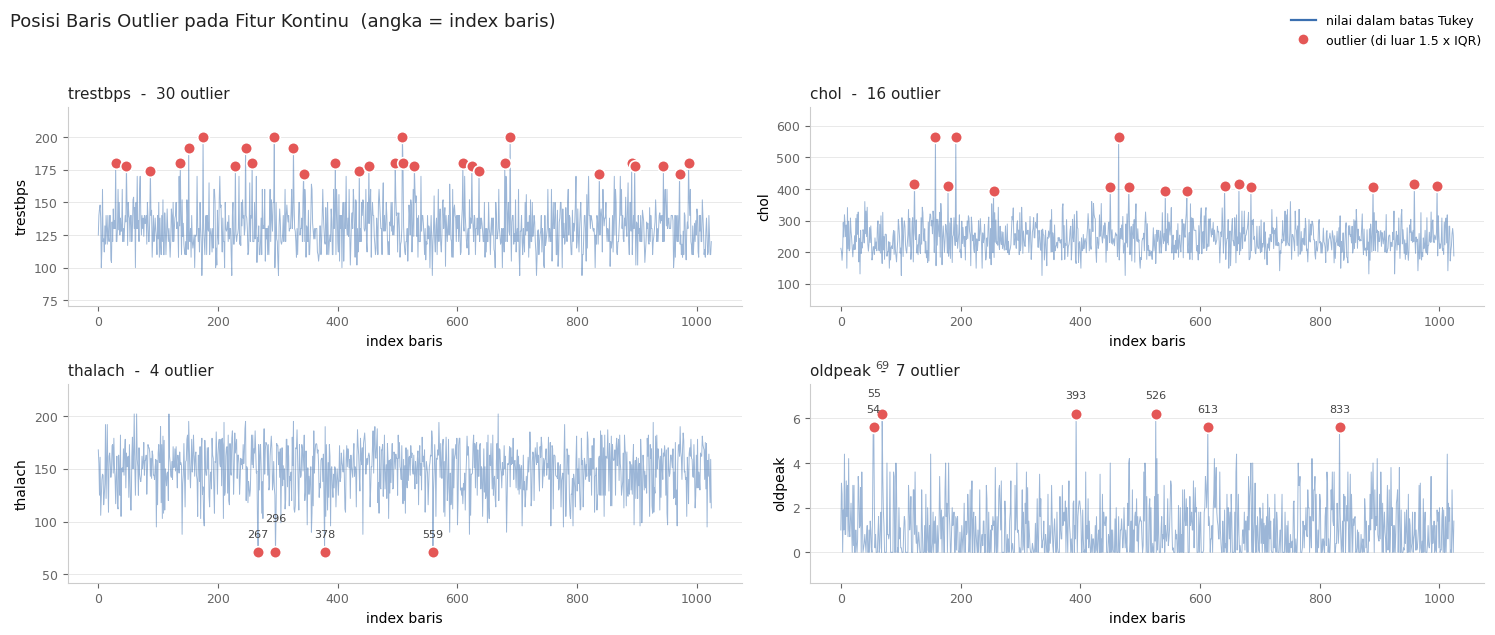

In [102]:
BIRU, MERAH, ABU = '#3A6FB0', '#E45756', '#666666'

def rapikan(ax):
    ax.grid(axis='y', color='#E9E9E9', linewidth=0.7)
    ax.set_axisbelow(True)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)
    for sisi in ('left', 'bottom'):
        ax.spines[sisi].set_color('#CCCCCC')
    ax.tick_params(colors=ABU, labelsize=9)

def label_index(ax, idx_list, y_of, rentang_x):
    """label index baris, dibuat bertingkat supaya tidak tumpang tindih"""
    tingkat, x_sebelum = 0, -np.inf
    for i in sorted(idx_list):
        tingkat = (tingkat + 1) % 3 if (i - x_sebelum) < 0.04 * rentang_x else 0
        ax.annotate(str(i), (i, y_of(i)), textcoords='offset points',
                    xytext=(0, 11 + 11 * tingkat), ha='center', fontsize=8, color='#444')
        x_sebelum = i

# ================== fitur KONTINU -> line chart ==================
kontinu_out = [c for c in KONTINU if c in set(outlier_rows['fitur'])]
fig, axes = plt.subplots(2, 2, figsize=(15, 6.4))
axes = axes.ravel()

for ax, col in zip(axes, kontinu_out):
    idx_out = sorted(outlier_rows.loc[outlier_rows['fitur'] == col, 'baris'])
    ax.plot(data.index, data[col], color=BIRU, linewidth=0.7, alpha=0.5, zorder=1)
    ax.scatter(idx_out, data.loc[idx_out, col], s=70, color=MERAH,
               edgecolors='white', linewidths=1.2, zorder=3)
    if len(idx_out) <= 10:                       # label hanya kalau sedikit
        label_index(ax, idx_out, lambda i: data.at[i, col], len(data))
    ax.margins(y=0.22)
    ax.set_title(f'{col}  -  {len(idx_out)} outlier', fontsize=11, loc='left', color='#222')
    ax.set_xlabel('index baris'); ax.set_ylabel(col)
    rapikan(ax)

for ax in axes[len(kontinu_out):]:
    ax.set_visible(False)

garis = plt.Line2D([], [], color=BIRU, linewidth=1.6, label='nilai dalam batas Tukey')
titik = plt.Line2D([], [], color=MERAH, marker='o', linestyle='none', markersize=8,
                   markeredgecolor='white', label='outlier (di luar 1.5 x IQR)')
fig.legend(handles=[garis, titik], frameon=False, fontsize=9,
           loc='upper right', bbox_to_anchor=(0.995, 0.995))
fig.suptitle('Posisi Baris Outlier pada Fitur Kontinu  (angka = index baris)',
             fontsize=13, x=0.007, ha='left', color='#222')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

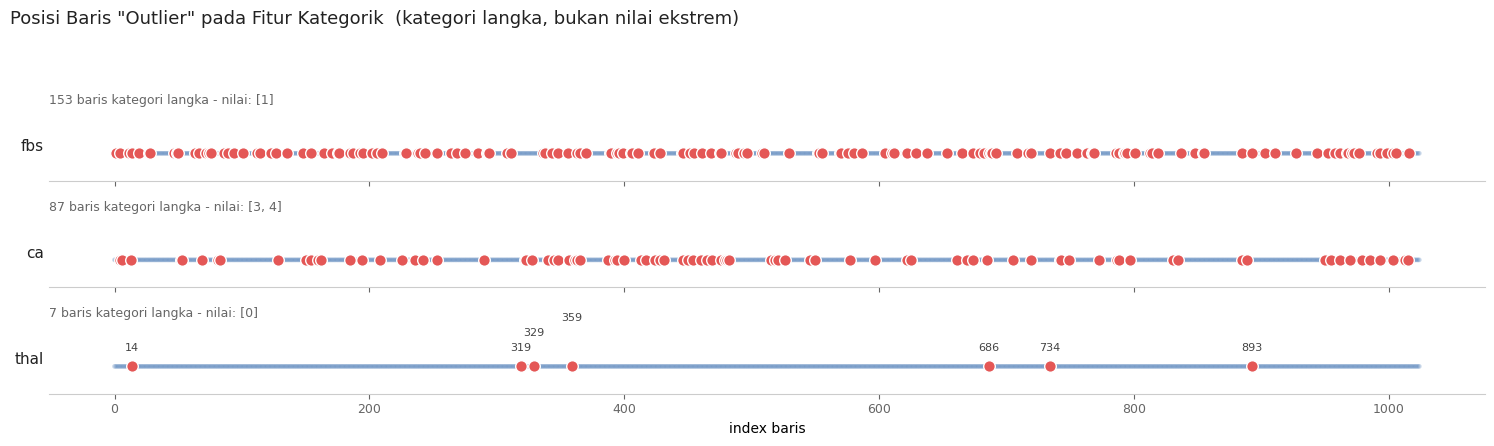

In [103]:
# ================== fitur KATEGORIK -> strip plot ==================
# line chart tidak informatif untuk fitur biner/ordinal, jadi posisinya
# ditampilkan sebagai strip di sepanjang index baris.
kategorik_out = [c for c in ['fbs', 'ca', 'thal'] if c in set(outlier_rows['fitur'])]

fig, axes = plt.subplots(len(kategorik_out), 1,
                         figsize=(15, 1.5 * len(kategorik_out)), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, kategorik_out):
    idx_out = sorted(outlier_rows.loc[outlier_rows['fitur'] == col, 'baris'])
    lain = data.index.difference(idx_out)
    ax.scatter(lain, np.zeros(len(lain)), s=12, color=BIRU, alpha=0.25,
               edgecolors='none', zorder=1)
    ax.scatter(idx_out, np.zeros(len(idx_out)), s=70, color=MERAH,
               edgecolors='white', linewidths=1.0, zorder=3)
    if len(idx_out) <= 10:
        label_index(ax, idx_out, lambda i: 0, len(data))
    ax.set_yticks([]); ax.set_ylim(-0.6, 0.9)
    nilai_langka = sorted(int(v) for v in data.loc[idx_out, col].unique())
    ax.set_ylabel(col, rotation=0, ha='right', va='center', fontsize=11, color='#222')
    ax.set_title(f'{len(idx_out)} baris kategori langka - nilai: {nilai_langka}',
                 fontsize=9, loc='left', color=ABU)
    for sisi in ('top', 'right', 'left'):
        ax.spines[sisi].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors=ABU, labelsize=9)

axes[-1].set_xlabel('index baris')
fig.suptitle('Posisi Baris "Outlier" pada Fitur Kategorik  (kategori langka, bukan nilai ekstrem)',
             fontsize=13, x=0.007, ha='left', color='#222')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

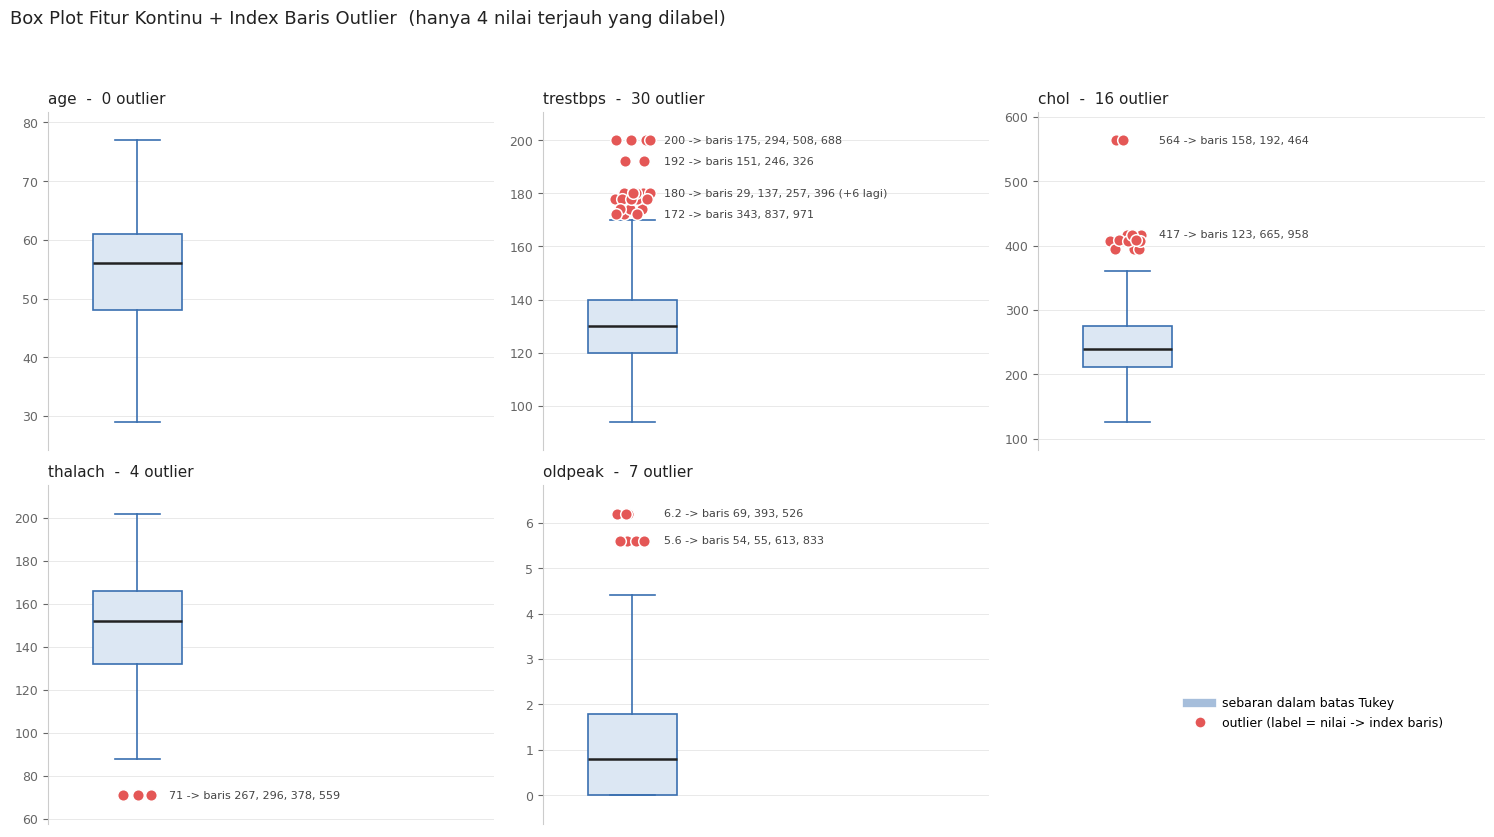

In [104]:
# ================== box plot + index baris ==================
MAKS_NILAI_DILABEL = 4     # berapa banyak NILAI ekstrem yang diberi label

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.ravel()
rng = np.random.default_rng(7)

for ax, col in zip(axes, KONTINU):
    ax.boxplot(data[col].dropna(), widths=0.4, patch_artist=True,
               boxprops=dict(facecolor='#DCE7F3', edgecolor=BIRU, linewidth=1.2),
               medianprops=dict(color='#222', linewidth=1.8),
               whiskerprops=dict(color=BIRU, linewidth=1.2),
               capprops=dict(color=BIRU, linewidth=1.2),
               showfliers=False)                    # titik outlier digambar manual

    sub = outlier_rows[outlier_rows['fitur'] == col]
    if len(sub):
        ax.scatter(1 + rng.uniform(-0.08, 0.08, size=len(sub)), sub['nilai'],
                   s=70, color=MERAH, edgecolors='white', linewidths=1.1, zorder=3)

        # kelompokkan per NILAI supaya baris bernilai kembar jadi satu label
        def ringkas(s):
            b = sorted(s)
            return ', '.join(map(str, b[:4])) + (f' (+{len(b)-4} lagi)' if len(b) > 4 else '')

        grup = (sub.groupby('nilai')
                   .agg(baris=('baris', ringkas), arah=('arah', 'first'),
                        bb=('batas_bawah', 'first'), ba=('batas_atas', 'first'))
                   .reset_index())
        grup['jarak'] = np.where(grup['arah'] == 'atas',
                                 grup['nilai'] - grup['ba'], grup['bb'] - grup['nilai'])

        # ambil yang terjauh, lewati yang posisinya terlalu berdempetan
        span = data[col].max() - data[col].min()
        dipilih, y_dipakai = [], []
        for _, r in grup.sort_values('jarak', ascending=False).iterrows():
            if len(dipilih) >= MAKS_NILAI_DILABEL:
                break
            if all(abs(r['nilai'] - y) > 0.07 * span for y in y_dipakai):
                dipilih.append(r); y_dipakai.append(r['nilai'])

        for r in dipilih:
            ax.annotate(f"{r['nilai']:g} -> baris {r['baris']}", (1.14, r['nilai']),
                        ha='left', va='center', fontsize=8, color='#444')

    ax.set_title(f'{col}  -  {len(sub)} outlier', fontsize=11, loc='left', color='#222')
    ax.set_xticks([]); ax.set_xlim(0.6, 2.6); ax.margins(y=0.1)
    ax.grid(axis='y', color='#E9E9E9', linewidth=0.7)
    ax.set_axisbelow(True)
    for sisi in ('top', 'right', 'bottom'):
        ax.spines[sisi].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.tick_params(colors=ABU, labelsize=9)

for ax in axes[len(KONTINU):]:
    ax.set_visible(False)

kotak = plt.Line2D([], [], color=BIRU, linewidth=6, alpha=0.45, label='sebaran dalam batas Tukey')
titik = plt.Line2D([], [], color=MERAH, marker='o', linestyle='none', markersize=8,
                   markeredgecolor='white', label='outlier (label = nilai -> index baris)')
fig.legend(handles=[kotak, titik], frameon=False, fontsize=9,
           loc='lower right', bbox_to_anchor=(0.97, 0.12))
fig.suptitle('Box Plot Fitur Kontinu + Index Baris Outlier  (hanya 4 nilai terjauh yang dilabel)',
             fontsize=13, x=0.007, ha='left', color='#222')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [105]:
# ---- kenapa banyak nilai outlier yang kembar? cek duplikasi baris ----
n_salinan_berlebih = data.duplicated(keep='first').sum()   # baris ke-2 dst dari tiap kembaran
n_unik             = len(data.drop_duplicates())
n_punya_kembaran   = data.duplicated(keep=False).sum()     # semua anggota grup kembaran

print(f'Total baris                     : {len(data)}')
print(f'Baris unik                      : {n_unik}')
print(f'Salinan berlebih (bisa dihapus) : {n_salinan_berlebih}')
print(f'Baris yang punya kembaran       : {n_punya_kembaran}  -> semua baris terlibat duplikasi')

print('\nContoh: baris 54 dan 55, dua-duanya outlier oldpeak dan isinya identik')
print(data.loc[[54, 55]])

out_dup = data.loc[idx_kontinu].duplicated(keep=False).sum()
print(f'\nDari {len(idx_kontinu)} baris outlier kontinu, {out_dup} punya kembaran persis.')
print('Artinya jumlah outlier di atas ikut terlipat oleh duplikasi,')
print('bukan sebanyak itu pasien aslinya.')

Total baris                     : 1025
Baris unik                      : 302
Salinan berlebih (bisa dihapus) : 723
Baris yang punya kembaran       : 1025  -> semua baris terlibat duplikasi

Contoh: baris 54 dan 55, dua-duanya outlier oldpeak dan isinya identik
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
54   55    1   0       140   217    0        1      111      1      5.6      0   0     3       0
55   55    1   0       140   217    0        1      111      1      5.6      0   0     3       0

Dari 57 baris outlier kontinu, 57 punya kembaran persis.
Artinya jumlah outlier di atas ikut terlipat oleh duplikasi,
bukan sebanyak itu pasien aslinya.


### notes lokasi outlier

1. **Fitur kontinu** (yang benar-benar bermakna sebagai nilai ekstrem):
   - `trestbps` 30 baris, semuanya di sisi atas (>170 mmHg). Paling ekstrem 200 mmHg di baris 175, 294, 508, 688.
   - `chol` 16 baris, semuanya di sisi atas (>371 mg/dl). Paling ekstrem 564 mg/dl di baris 158, 192, 464.
   - `oldpeak` 7 baris, semuanya di sisi atas (>4.5). Paling ekstrem 6.2 di baris 69, 393, 526.
   - `thalach` 4 baris, semuanya di sisi bawah (71 bpm) di baris 267, 296, 378, 559.
   - `age` tidak punya outlier sama sekali.
2. **Fitur kategorik** (`fbs`, `ca`, `thal`) terdeteksi "outlier" hanya karena kategorinya jarang muncul, bukan karena nilainya ekstrem. Jangan diperlakukan sebagai outlier numerik.
3. `ca` bernilai 3 dan 4 terdeteksi outlier, padahal dokumentasi menyebut rentangnya 0-3. Nilai 4 kemungkinan besar adalah kode *missing value*. Hal yang sama berlaku untuk `thal` bernilai 0 (dokumentasi: 3, 6, 7). Dua hal ini wajib dibereskan di tahap preprocessing.
4. **Banyak nilai outlier muncul berulang persis** karena dataset ini mengandung 723 baris duplikat; baris uniknya hanya 302. Jadi satu pasien ekstrem bisa terhitung beberapa kali. Ini berpengaruh ke semua statistik EDA di atas dan harus ditangani sebelum modeling.
5. Sesuai catatan sebelumnya, nilai ekstrem medis jangan langsung dibuang. Tekanan darah 200 mmHg dan kolesterol 564 mg/dl itu klinis nyata, bukan salah input.

### notes: baris mana yang benar-benar perlu difilter?

Diperiksa dari `outlier_rows.csv` (305 deteksi, 256 baris unik), dicek satu per satu
terhadap konteks medis tiap fitur dan terhadap isi lengkap barisnya.

**Kesimpulan singkat: hampir semua outlier itu SAH secara klinis dan tidak boleh dibuang.
Yang benar-benar wajib difilter/ditangani hanya 25 baris berkode invalid, plus 723 baris duplikat.**

#### 1. Verdict per fitur

| Fitur | Deteksi (dari 1025) | Pasien unik | Nilai | Penjelasan ilmiah | Tindakan |
|---|---|---|---|---|---|
| `trestbps` | 30 | 9 | 172-200 mmHg | Hipertensi derajat 2 (>=160) sampai krisis hipertensi (>=180). Nilai yang lazim ditemui di poliklinik jantung, bukan salah input. | **Pertahankan** |
| `chol` | 16 | 5 | 394-564 mg/dl | Semuanya perempuan usia 56-67. Nilai >=400 mg/dl konsisten dengan hiperkolesterolemia familial. Nilai 564 mg/dl memang ekstrem tapi masih dalam rentang yang mungkin secara biologis. | **Pertahankan** |
| `oldpeak` | 7 | 2 | 5.6 dan 6.2 mm | Konsisten secara internal: kedua pasien punya `slope`=0 (ST menurun) dan salah satunya `ca`=3 (tiga pembuluh tersumbat). Depresi ST besar memang gejala iskemia berat. | **Pertahankan** |
| `thalach` | 4 | 1 (baris 267) | 71 bpm | Laki-laki 67 tahun. Bukan nilai terisolasi: ada tetangga di 88 dan 90 bpm, jadi ekornya nyata. Cocok dengan chronotropic incompetence atau efek beta-blocker. | **Pertahankan**, cukup ditandai |
| `fbs` | 153 | - | 1 | **Bukan outlier.** Q1=Q3=0 sehingga IQR=0, akibatnya semua nilai 1 otomatis dianggap outlier. Ini hanya prevalensi gula darah puasa >120 mg/dl sebesar 14.9%, wajar untuk populasi pasien jantung. | **Abaikan** (artefak metode) |
| `ca` = 3 | 69 | - | 3 | Nilai valid sesuai dokumentasi (0-3), hanya jarang muncul. | **Pertahankan** |
| `ca` = 4 | **18** | **3** | 4 | **Invalid.** Dokumentasi menyebut rentang 0-3. Nilai 4 adalah kode *missing* dari data UCI asli. | **Wajib ditangani** |
| `thal` = 0 | **7** | **3** | 0 | **Invalid.** Kategori sahnya hanya 1/2/3. Nilai 0 adalah kode *missing*. | **Wajib ditangani** |

#### 2. Baris yang perlu difilter / ditandai missing

- `ca == 4` -> baris **52, 83, 128, 208, 242, 290, 340, 348, 417, 428, 465, 521, 597, 743, 749, 831, 970, 993** (18 baris, hanya 3 pasien unik)
- `thal == 0` -> baris **14, 319, 329, 359, 686, 734, 893** (7 baris, hanya 3 pasien unik)
- Total **25 baris dari 1025 (2.4%)**, yang setelah deduplikasi hanya menyisakan **6 pasien unik dari 302 (2.0%)**
- Tidak ada irisan antara kedua kelompok

Perlakuannya: jangan hapus barisnya, tapi ubah nilai invalid tersebut jadi `NaN` lalu imputasi.
Membuang seluruh baris berarti ikut membuang 12 fitur lain yang datanya sehat.
Ini sudah dikerjakan di **STEP 3** di bawah.

#### 3. Masalah yang jauh lebih besar daripada outlier: duplikasi

723 dari 1025 baris adalah salinan; pasien uniknya cuma 302. Semua angka outlier di atas
ikut terlipat karenanya (contoh: `chol` 564 mg/dl terhitung 3 kali padahal hanya 1 pasien).
Deduplikasi harus dilakukan **sebelum** menghitung ulang batas IQR, kalau tidak batasnya
bias mengikuti pasien yang kebetulan tersalin lebih banyak. Ditangani di **STEP 1**.

#### 4. Temuan tambahan saat verifikasi: arti label `target` patut dicurigai terbalik

Saat mengecek konsistensi klinis baris-baris outlier, muncul pola yang konsisten
ke arah yang berlawanan dengan nama kolomnya (dihitung dari 302 baris unik):

| Pemeriksaan | Proporsi `target` = 1 | Yang diharapkan kalau 1 = sakit |
|---|---|---|
| `ca` = 0 (tidak ada pembuluh tersumbat) | 74.3% | seharusnya rendah |
| `ca` = 3 (tiga pembuluh tersumbat) | 15.0% | seharusnya tinggi |
| `cp` = 0 (asimtomatik) | 27.3% | seharusnya rendah |
| `exang` = 1 (angina saat olahraga) | 23.2% | seharusnya tinggi |
| `thal` = 3 (defek reversibel) | 23.9% | seharusnya tinggi |
| rata-rata `thalach` saat `target` = 1 | 158.4 bpm vs 139.1 bpm | seharusnya lebih rendah |

Enam indikator independen semuanya searah, jadi besar kemungkinan `target` = 1 berarti
**tidak sakit jantung**, bukan sebaliknya. Perlu dikonfirmasi ke berkas UCI asli sebelum
menarik kesimpulan di makalah, karena judul grafik distribusi target di atas
(0 = tidak sakit, 1 = sakit) ikut terpengaruh.

Catatan terkait: pengecekan yang sama menunjukkan `slope` juga bukan 0=upsloping seperti
dugaan awal. Rata-rata `oldpeak` per `slope` adalah 2.71 / 1.43 / 0.41 untuk slope 0/1/2,
jadi slope=0 justru ST menurun (*downsloping*) dan slope=2 adalah ST menanjak (*upsloping*).

# Further Preprocessing: Mengenal Data dan Asosiasi Antar Fitur

Tahap ini **belum masuk modelling**. Tujuannya dua: membersihkan data dari noise yang
benar-benar noise, lalu mengukur ulang hubungan antar fitur dengan alat yang tepat.

### Metode filter mana yang cocok untuk imputasi?

Sebelum memilih metode, pisahkan dulu dua hal yang sering tertukar:

| Temuan | Sifatnya | Tindakan |
|---|---|---|
| `trestbps` 200 mmHg, `chol` 564 mg/dl, `oldpeak` 6.2, `thalach` 71 | nilai klinis nyata, ekstrem tapi valid | **jangan diimputasi**, biarkan apa adanya |
| `ca` = 4 dan `thal` = 0 | kode di luar dokumentasi, ini *missing value* yang disamarkan | **diimputasi** |
| 723 baris duplikat | kesalahan penyusunan dataset | **dihapus** |

**Filter sinyal tidak cocok di sini.** Moving average, median filter, Hampel filter, dan
Savitzky-Golay semuanya mengasumsikan urutan data punya makna, seperti pada deret waktu
atau sinyal sensor. Pada dataset ini sumbu x line chart hanya nomor baris, dan urutannya
arbitrer. Menghaluskan nilai baris ke-100 memakai baris ke-99 dan ke-101 berarti mencampur
data tiga pasien yang tidak berhubungan. Klaim ini dibuktikan secara empiris di Step 2 lewat
uji autokorelasi.

**Yang dipakai:** imputasi modus untuk `ca` dan `thal`, dibandingkan dengan KNN imputer
supaya pilihannya punya dasar, bukan sekadar yang paling gampang.

In [106]:
# ===================== STEP 1: hapus duplikat =====================
if not isinstance(globals().get("data"), pd.DataFrame):
    data = pd.read_csv("heart_disease_dataset.csv")

df = data.drop_duplicates().reset_index(drop=True)
print(f'sebelum : {data.shape}')
print(f'sesudah : {df.shape}')
print(f'dibuang : {len(data) - len(df)} baris duplikat')

# apakah duplikat itu yang bikin korelasi rendah? bandingkan langsung
korelasi_dedup = pd.DataFrame({
    'sebelum_1025': data.corr(numeric_only=True)['target'].drop('target'),
    'sesudah_302':  df.corr(numeric_only=True)['target'].drop('target'),
})
korelasi_dedup['selisih'] = korelasi_dedup['sesudah_302'] - korelasi_dedup['sebelum_1025']
korelasi_dedup = korelasi_dedup.reindex(
    korelasi_dedup['sesudah_302'].abs().sort_values(ascending=False).index).round(3)

print('\n=== Korelasi Pearson ke target: sebelum vs sesudah dedup ===')
print(korelasi_dedup.to_string())
print(f'\nPergeseran terbesar hanya {korelasi_dedup["selisih"].abs().max():.3f} (pada ca).')
print('Kesimpulan: duplikasi BUKAN penyebab korelasi rendah. Korelasinya memang segitu.')

sebelum : (1025, 14)
sesudah : (302, 14)
dibuang : 723 baris duplikat

=== Korelasi Pearson ke target: sebelum vs sesudah dedup ===
          sebelum_1025  sesudah_302  selisih
exang           -0.438       -0.436    0.002
cp               0.435        0.432   -0.003
oldpeak         -0.438       -0.429    0.009
thalach          0.423        0.420   -0.003
ca              -0.382       -0.409   -0.027
slope            0.346        0.344   -0.002
thal            -0.338       -0.343   -0.005
sex             -0.280       -0.284   -0.004
age             -0.229       -0.221    0.008
trestbps        -0.139       -0.146   -0.007
restecg          0.134        0.135    0.000
chol            -0.100       -0.081    0.019
fbs             -0.041       -0.027    0.014

Pergeseran terbesar hanya 0.027 (pada ca).
Kesimpulan: duplikasi BUKAN penyebab korelasi rendah. Korelasinya memang segitu.


In [107]:
# ===================== STEP 2: apakah filter sinyal masuk akal? =====================
# Filter seperti moving average / median filter baru berguna kalau urutan baris
# punya struktur. Diuji dengan autokorelasi: kalau ~0, urutan baris tidak bermakna.
KONTINU = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
LAG = [1, 2, 3]

autokorelasi = pd.DataFrame(
    {f'lag_{k}': [df[c].autocorr(k) for c in KONTINU] for k in LAG},
    index=KONTINU).round(3)

batas = 1.96 / np.sqrt(len(df))          # batas signifikansi 95%
lewat = autokorelasi.abs() > batas
autokorelasi['n_lewat_batas'] = lewat.sum(axis=1)

print('=== Autokorelasi antar baris berurutan ===')
print(autokorelasi.to_string())
print(f'\nBatas signifikansi 95% : +/- {batas:.3f}')

n_uji, n_lewat = lewat.size, int(lewat.to_numpy().sum())
print(f'Melewati batas         : {n_lewat} dari {n_uji} uji '
      f'(kebetulan yang diharapkan: {0.05 * n_uji:.1f})')

if n_lewat:
    for (f, l) in zip(*np.where(lewat.to_numpy())):
        print(f'  -> {KONTINU[f]} pada lag {LAG[l]}: {autokorelasi.iloc[f, l]:+.3f}')

print('\nBacaan: tidak ada pola yang konsisten. Data berurutan yang sungguhan akan')
print('menunjukkan lag-1 positif besar lalu meluruh; di sini lag-1 semuanya di bawah 0.1')
print('dan satu-satunya pelanggaran batas muncul di lag yang lebih jauh, persis sebanyak')
print('yang diharapkan muncul karena kebetulan dari 15 kali uji.')
print('\nKESIMPULAN: urutan baris tidak membawa informasi, jadi smoothing/filter sinyal')
print('(moving average, median filter, Hampel, Savitzky-Golay) TIDAK dipakai.')
print('Yang dipakai untuk kode invalid: imputasi biasa.')

=== Autokorelasi antar baris berurutan ===
          lag_1  lag_2  lag_3  n_lewat_batas
age       0.010 -0.037 -0.108              0
trestbps  0.055 -0.079 -0.078              0
chol     -0.096  0.190 -0.090              1
thalach  -0.043  0.082 -0.026              0
oldpeak   0.057  0.053 -0.024              0

Batas signifikansi 95% : +/- 0.113
Melewati batas         : 1 dari 15 uji (kebetulan yang diharapkan: 0.8)
  -> chol pada lag 2: +0.190

Bacaan: tidak ada pola yang konsisten. Data berurutan yang sungguhan akan
menunjukkan lag-1 positif besar lalu meluruh; di sini lag-1 semuanya di bawah 0.1
dan satu-satunya pelanggaran batas muncul di lag yang lebih jauh, persis sebanyak
yang diharapkan muncul karena kebetulan dari 15 kali uji.

KESIMPULAN: urutan baris tidak membawa informasi, jadi smoothing/filter sinyal
(moving average, median filter, Hampel, Savitzky-Golay) TIDAK dipakai.
Yang dipakai untuk kode invalid: imputasi biasa.


In [108]:
# ===================== STEP 3: tandai kode invalid sebagai missing =====================
# ca: dokumentasi menyebut 0-3, tapi ada nilai 4
# thal: dokumentasi menyebut 3 kategori, tapi ada nilai 0
INVALID = {'ca': [4], 'thal': [0]}

print('=== Distribusi sebelum ditandai ===')
for kol, nilai in INVALID.items():
    hitung = {int(k): int(v) for k, v in df[kol].value_counts().sort_index().items()}
    print(f'{kol:6} {hitung}   <- invalid: {nilai}')

baris_invalid = df[(df['ca'] == 4) | (df['thal'] == 0)]
print(f'\n=== {len(baris_invalid)} baris terdampak dari {len(df)} ({len(baris_invalid)/len(df):.1%}) ===')
print(baris_invalid)

for kol, nilai in INVALID.items():
    df.loc[df[kol].isin(nilai), kol] = np.nan

print('\n=== Missing value setelah ditandai ===')
print(df.isna().sum()[lambda s: s > 0].to_string())

=== Distribusi sebelum ditandai ===
ca     {0: 175, 1: 65, 2: 38, 3: 20, 4: 4}   <- invalid: [4]
thal   {0: 2, 1: 18, 2: 165, 3: 117}   <- invalid: [0]

=== 6 baris terdampak dari 302 (2.0%) ===
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
14    52    1   0       128   204    1        1      156      1      1.0      1   0     0       0
49    38    1   2       138   175    0        1      173      0      0.0      2   4     2       1
108   52    1   2       138   223    0        1      169      0      0.0      2   4     2       1
212   53    0   2       128   216    0        0      115      0      0.0      2   0     0       1
227   43    1   0       132   247    1        0      143      1      0.1      1   4     3       0
269   58    1   1       125   220    0        1      144      0      0.4      1   4     3       1

=== Missing value setelah ditandai ===
ca      4
thal    2


In [109]:
# ===================== STEP 4: imputasi, modus vs KNN =====================
from sklearn.impute import KNNImputer

modus = {kol: df[kol].mode()[0] for kol in INVALID}
print('Nilai modus:', {k: int(v) for k, v in modus.items()})

df_modus = df.fillna(modus)

knn = KNNImputer(n_neighbors=5, weights='distance')
df_knn = pd.DataFrame(knn.fit_transform(df), columns=df.columns)
df_knn[['ca', 'thal']] = df_knn[['ca', 'thal']].round().astype(int)

gabung = lambda d, idx: d.loc[idx, ['ca', 'thal']].astype(int).astype(str).agg(' / '.join, axis=1)
banding = pd.DataFrame({
    'sebelum (ca / thal)': baris_invalid[['ca', 'thal']].astype(int).astype(str).agg(' / '.join, axis=1),
    'imputasi modus':      gabung(df_modus, baris_invalid.index),
    'imputasi KNN':        gabung(df_knn, baris_invalid.index),
})
print('\n=== Hasil kedua metode pada 6 baris yang bermasalah ===')
print(banding.to_string())

beda = (df_modus[['ca', 'thal']].to_numpy() != df_knn[['ca', 'thal']].to_numpy()).sum()
print(f'\nSel yang berbeda antara modus dan KNN : {beda} dari {df_modus.shape[0] * 2}')

for nama, d_ in [('modus', df_modus), ('KNN  ', df_knn)]:
    r = d_.corr(numeric_only=True)['target'][['ca', 'thal']]
    print(f'  korelasi ke target versi {nama} : ca={r["ca"]:+.4f}  thal={r["thal"]:+.4f}')

print('\nSelisihnya di angka ketiga di belakang koma. Untuk 6 baris dari 302,')
print('metode canggih tidak memberi keuntungan berarti -> dipilih MODUS karena lebih sederhana')
print('dan tidak mengarang nilai baru pada fitur kategorik.')

df = df_modus.copy()
df['ca'] = df['ca'].astype(int)
df['thal'] = df['thal'].astype(int)

print(f'\nData bersih: {df.shape}')
print('ca  :', {int(k): int(v) for k, v in df['ca'].value_counts().sort_index().items()})
print('thal:', {int(k): int(v) for k, v in df['thal'].value_counts().sort_index().items()})

Nilai modus: {'ca': 0, 'thal': 2}

=== Hasil kedua metode pada 6 baris yang bermasalah ===
    sebelum (ca / thal) imputasi modus imputasi KNN
14                0 / 0          0 / 2        0 / 2
49                4 / 2          0 / 2        0 / 2
108               4 / 2          0 / 2        1 / 2
212               0 / 0          0 / 2        0 / 3
227               4 / 3          0 / 3        1 / 3
269               4 / 3          0 / 3        2 / 3

Sel yang berbeda antara modus dan KNN : 4 dari 604
  korelasi ke target versi modus : ca=-0.4639  thal=-0.3623
  korelasi ke target versi KNN   : ca=-0.4575  thal=-0.3565

Selisihnya di angka ketiga di belakang koma. Untuk 6 baris dari 302,
metode canggih tidak memberi keuntungan berarti -> dipilih MODUS karena lebih sederhana
dan tidak mengarang nilai baru pada fitur kategorik.

Data bersih: (302, 14)
ca  : {0: 179, 1: 65, 2: 38, 3: 20}
thal: {1: 18, 2: 167, 3: 117}


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [110]:
# ===================== STEP 5: tetapkan tipe/peran tiap fitur =====================
# Ini langkah kunci. Salah menetapkan tipe = salah memilih ukuran korelasi.
BINER     = ['sex', 'fbs', 'exang', 'target']
NOMINAL   = ['cp', 'restecg', 'thal']          # kategori tanpa urutan
ORDINAL   = ['slope', 'ca']                    # kategori dengan urutan
KATEGORIK = BINER + NOMINAL + ORDINAL

peran = {}
for c in KONTINU: peran[c] = 'kontinu'
for c in BINER:   peran[c] = 'biner'
for c in NOMINAL: peran[c] = 'nominal'
for c in ORDINAL: peran[c] = 'ordinal'

profil = pd.DataFrame({
    'tipe':     pd.Series(peran),
    'n_unik':   df.nunique(),
    'missing':  df.isna().sum(),
    'min':      df.min(numeric_only=True),
    'median':   df.median(numeric_only=True),
    'mean':     df.mean(numeric_only=True).round(2),
    'max':      df.max(numeric_only=True),
    'skew':     df.skew(numeric_only=True).round(2),
    'kurtosis': df.kurtosis(numeric_only=True).round(2),
}).loc[df.columns]

print('=== Profil fitur setelah dibersihkan ===')
print(profil.to_string())
print('\nCatatan: cp, restecg, thal disimpan sebagai angka tapi TIDAK berurutan.')
print('Menghitung Pearson pada fitur seperti ini akan meremehkan hubungannya.')

=== Profil fitur setelah dibersihkan ===
             tipe  n_unik  missing    min  median    mean    max  skew  kurtosis
age       kontinu      41        0   29.0    55.5   54.42   77.0 -0.20     -0.53
sex         biner       2        0    0.0     1.0    0.68    1.0 -0.79     -1.39
cp        nominal       4        0    0.0     1.0    0.96    3.0  0.49     -1.18
trestbps  kontinu      49        0   94.0   130.0  131.60  200.0  0.72      0.92
chol      kontinu     152        0  126.0   240.5  246.50  564.0  1.15      4.54
fbs         biner       2        0    0.0     0.0    0.15    1.0  1.98      1.94
restecg   nominal       3        0    0.0     1.0    0.53    2.0  0.17     -1.36
thalach   kontinu      91        0   71.0   152.5  149.57  202.0 -0.53     -0.06
exang       biner       2        0    0.0     0.0    0.33    1.0  0.74     -1.47
oldpeak   kontinu      40        0    0.0     0.8    1.04    6.2  1.27      1.57
slope     ordinal       3        0    0.0     1.0    1.40    2.0 -0.

In [111]:
# ===================== STEP 6: seberapa besar outlier menggeser statistik? =====================
# Bukan untuk membuang outlier, tapi untuk tahu seberapa besar pengaruhnya.
diag = []
for c in KONTINU:
    s = df[c]
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    out = s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)]
    wins = s.clip(s.quantile(.01), s.quantile(.99))      # winsorize 1%-99%, simulasi saja
    diag.append({
        'fitur': c,
        'n_outlier': len(out),
        'mean': round(s.mean(), 2),
        'median': round(s.median(), 2),
        'skew': round(s.skew(), 3),
        'skew_jika_winsor': round(wins.skew(), 3),
        'geser_mean_jika_winsor': round(wins.mean() - s.mean(), 3),
    })

print('=== Pengaruh outlier terhadap statistik ringkas ===')
print(pd.DataFrame(diag).set_index('fitur').to_string())
print('\nchol paling terpengaruh: skew turun dari 1.15 ke 0.61 kalau di-winsorize,')
print('tapi mean hanya bergeser 0.4 mg/dl. Jadi outlier chol memengaruhi BENTUK sebaran,')
print('bukan pusat datanya. Untuk EDA nilai aslinya dipertahankan.')

=== Pengaruh outlier terhadap statistik ringkas ===
          n_outlier    mean  median   skew  skew_jika_winsor  geser_mean_jika_winsor
fitur                                                                               
age               0   54.42    55.5 -0.204            -0.227                  -0.020
trestbps          9  131.60   130.0  0.717             0.604                  -0.066
chol              5  246.50   240.5  1.147             0.611                  -0.399
thalach           1  149.57   152.5 -0.533            -0.472                   0.069
oldpeak           5    1.04     0.8  1.266             1.028                  -0.012

chol paling terpengaruh: skew turun dari 1.15 ke 0.61 kalau di-winsorize,
tapi mean hanya bergeser 0.4 mg/dl. Jadi outlier chol memengaruhi BENTUK sebaran,
bukan pusat datanya. Untuk EDA nilai aslinya dipertahankan.


In [112]:
# ===================== STEP 7: ukuran asosiasi yang sesuai tipe fitur =====================
from scipy import stats

def cramers_v(x, y):
    """asosiasi kategorik vs kategorik, rentang 0-1, dengan koreksi bias Bergsma-Wicher"""
    tab = pd.crosstab(x, y)
    if min(tab.shape) < 2:
        return np.nan
    chi2 = stats.chi2_contingency(tab, correction=False)[0]
    n = tab.to_numpy().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - (r - 1) ** 2 / (n - 1)
    kcorr = k - (k - 1) ** 2 / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

def correlation_ratio(kategori, nilai):
    """eta: asosiasi kategorik vs kontinu, rentang 0-1"""
    kategori = np.asarray(kategori)
    nilai = np.asarray(nilai, dtype=float)
    rata_total = nilai.mean()
    ss_antar = sum(len(nilai[kategori == k]) * (nilai[kategori == k].mean() - rata_total) ** 2
                   for k in np.unique(kategori))
    ss_total = ((nilai - rata_total) ** 2).sum()
    return np.sqrt(ss_antar / ss_total) if ss_total > 0 else np.nan

kolom = df.columns.tolist()
asosiasi = pd.DataFrame(np.eye(len(kolom)), index=kolom, columns=kolom)
metode   = pd.DataFrame('', index=kolom, columns=kolom)

for i, a in enumerate(kolom):
    for b in kolom[i + 1:]:
        if peran[a] == 'kontinu' and peran[b] == 'kontinu':
            v, m = abs(stats.spearmanr(df[a], df[b]).statistic), 'spearman'
        elif peran[a] != 'kontinu' and peran[b] != 'kontinu':
            v, m = cramers_v(df[a], df[b]), 'cramersV'
        else:
            kat, kon = (a, b) if peran[a] != 'kontinu' else (b, a)
            v, m = correlation_ratio(df[kat], df[kon]), 'eta'
        asosiasi.loc[a, b] = asosiasi.loc[b, a] = v
        metode.loc[a, b] = metode.loc[b, a] = m

ke_target = pd.DataFrame({
    'asosiasi':     asosiasi['target'].drop('target'),
    'metode':       metode['target'].drop('target'),
    'tipe':         pd.Series(peran).drop('target'),
    'pearson_naif': df.corr(numeric_only=True)['target'].drop('target'),
})
ke_target['selisih'] = ke_target['asosiasi'] - ke_target['pearson_naif'].abs()
ke_target = ke_target.sort_values('asosiasi', ascending=False).round(3)

print('=== Asosiasi ke target: ukuran yang tepat vs Pearson naif ===')
print(ke_target.to_string())

tril = np.tril(np.ones(asosiasi.shape), k=-1).astype(bool)
pasangan = (asosiasi.where(tril).stack().rename('asosiasi').to_frame()
            .join(metode.where(tril).stack().rename('metode'))
            .sort_values('asosiasi', ascending=False).round(3))
pasangan.index.names = ['fitur_1', 'fitur_2']

print('\n=== 12 pasangan fitur dengan asosiasi terkuat ===')
print(pasangan.head(12).to_string())

=== Asosiasi ke target: ukuran yang tepat vs Pearson naif ===
          asosiasi    metode     tipe  pearson_naif  selisih
thal         0.522  cramersV  nominal        -0.362    0.160
cp           0.509  cramersV  nominal         0.432    0.077
ca           0.485  cramersV  ordinal        -0.464    0.021
exang        0.432  cramersV    biner        -0.436   -0.003
oldpeak      0.429       eta  kontinu        -0.429    0.000
thalach      0.420       eta  kontinu         0.420    0.000
slope        0.386  cramersV  ordinal         0.344    0.042
sex          0.278  cramersV    biner        -0.284   -0.005
age          0.221       eta  kontinu        -0.221   -0.000
restecg      0.160  cramersV  nominal         0.135    0.025
trestbps     0.146       eta  kontinu        -0.146    0.000
chol         0.081       eta  kontinu        -0.081    0.000
fbs          0.000  cramersV    biner        -0.027   -0.027

=== 12 pasangan fitur dengan asosiasi terkuat ===
                 asosiasi    meto

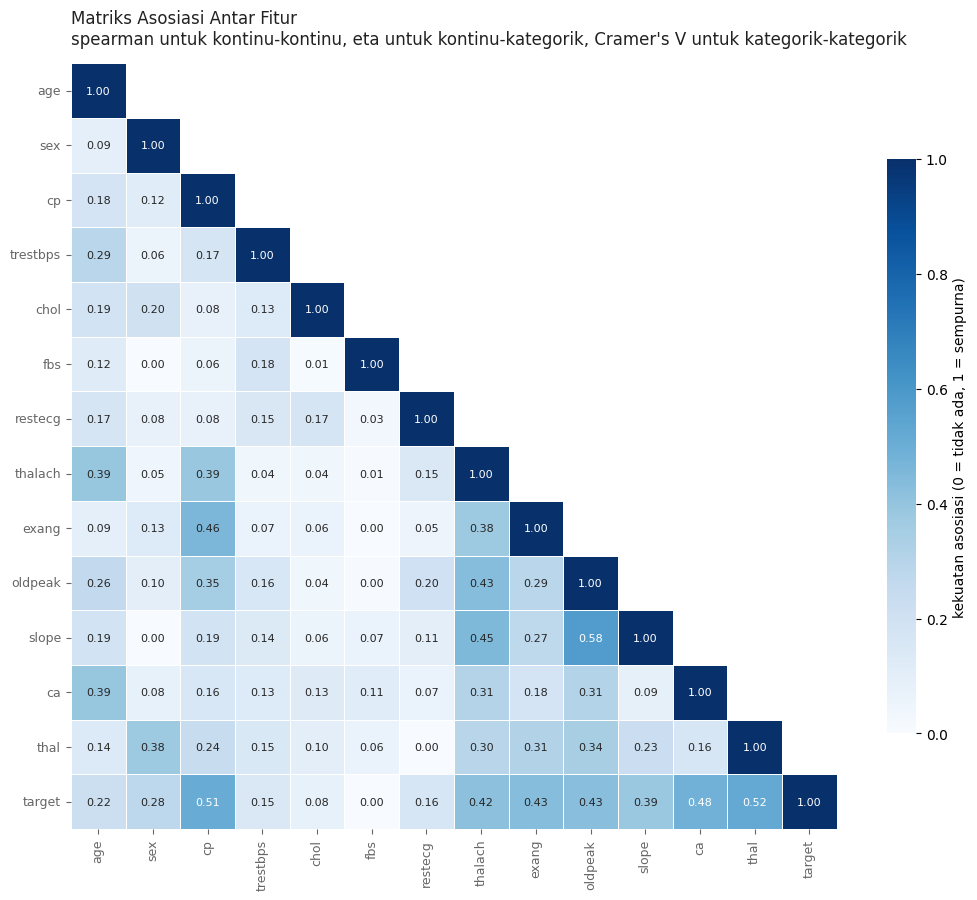

Semua nilai 0-1 dan tidak bertanda. Arah hubungan dibaca dari heatmap
Pearson/Spearman sebelumnya; matriks ini untuk membaca KEKUATANnya.


In [113]:
# ---------- heatmap matriks asosiasi ----------
mask = np.triu(np.ones_like(asosiasi, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(asosiasi.astype(float), mask=mask, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, square=True, linewidths=0.6, linecolor='white',
            cbar_kws={'shrink': 0.75, 'label': 'kekuatan asosiasi (0 = tidak ada, 1 = sempurna)'},
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Matriks Asosiasi Antar Fitur\n'
             'spearman untuk kontinu-kontinu, eta untuk kontinu-kategorik, '
             "Cramer's V untuk kategorik-kategorik",
             fontsize=12, pad=14, loc='left', color='#222')
ax.tick_params(colors='#666666', labelsize=9)
plt.tight_layout()
plt.show()

print('Semua nilai 0-1 dan tidak bertanda. Arah hubungan dibaca dari heatmap')
print('Pearson/Spearman sebelumnya; matriks ini untuk membaca KEKUATANnya.')

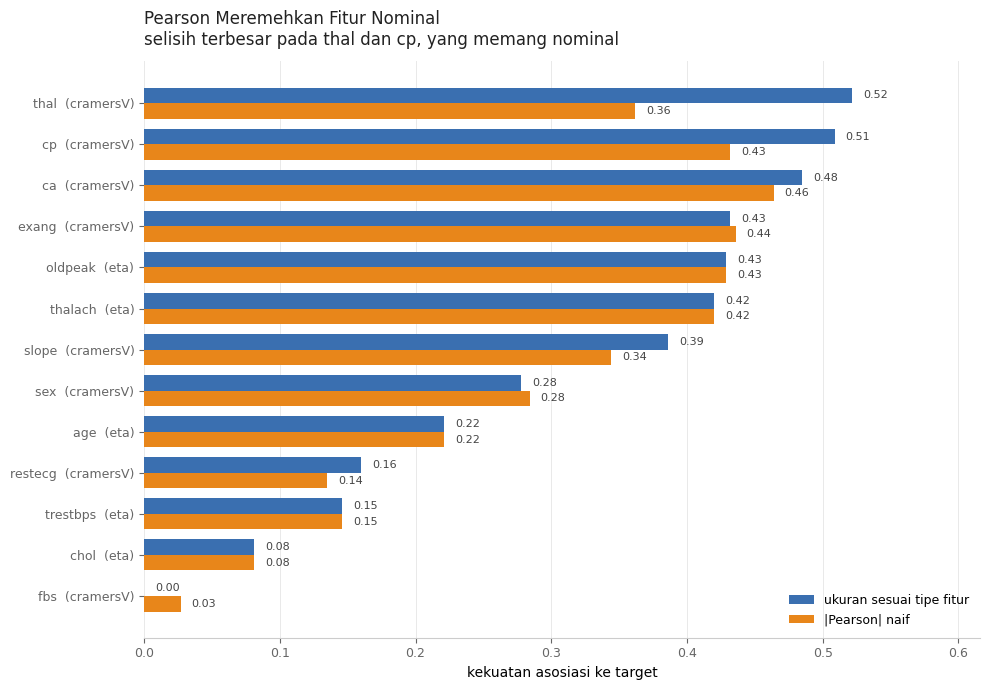

In [114]:
# ---------- bar: ukuran yang tepat vs Pearson naif ----------
BIRU, ORANYE, ABU = '#3A6FB0', '#E8861A', '#666666'

plot_df = ke_target.sort_values('asosiasi')
y = np.arange(len(plot_df))
tinggi = 0.38

fig, ax = plt.subplots(figsize=(10, 7))
b1 = ax.barh(y + tinggi / 2, plot_df['asosiasi'], height=tinggi, color=BIRU,
             label='ukuran sesuai tipe fitur')
b2 = ax.barh(y - tinggi / 2, plot_df['pearson_naif'].abs(), height=tinggi, color=ORANYE,
             label='|Pearson| naif')

for bars in (b1, b2):
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.008, bar.get_y() + bar.get_height() / 2, f'{w:.2f}',
                va='center', fontsize=8, color='#444')

ax.set_yticks(y)
ax.set_yticklabels([f'{i}  ({t})' for i, t in zip(plot_df.index, plot_df['metode'])], fontsize=9)
ax.set_xlabel('kekuatan asosiasi ke target')
ax.set_xlim(0, plot_df['asosiasi'].max() * 1.18)
ax.set_title('Pearson Meremehkan Fitur Nominal\n'
             'selisih terbesar pada thal dan cp, yang memang nominal',
             fontsize=12, loc='left', color='#222', pad=12)
ax.grid(axis='x', color='#E9E9E9', linewidth=0.7)
ax.set_axisbelow(True)
for sisi in ('top', 'right', 'left'):
    ax.spines[sisi].set_visible(False)
ax.spines['bottom'].set_color('#CCCCCC')
ax.tick_params(colors=ABU, labelsize=9)
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

In [115]:
# ===================== STEP 8: cek multikolinearitas + simpan =====================
# VIF dihitung manual (statsmodels tidak terpasang): regresi tiap fitur ke fitur lain.
X = df.drop(columns='target').astype(float)
Xs = (X - X.mean()) / X.std()

vif = {}
for c in Xs.columns:
    y_ = Xs[c].to_numpy()
    A = np.column_stack([np.ones(len(Xs)), Xs.drop(columns=c).to_numpy()])
    beta, *_ = np.linalg.lstsq(A, y_, rcond=None)
    r2 = 1 - ((y_ - A @ beta) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
    vif[c] = 1 / (1 - r2) if r2 < 1 else np.inf

vif_s = pd.Series(vif).sort_values(ascending=False).round(2)
print('=== VIF (Variance Inflation Factor) ===')
print(vif_s.to_string())
print(f'\nVIF tertinggi: {vif_s.max()} pada {vif_s.idxmax()}')
print('Ambang umum: >5 dicurigai, >10 multikolinear serius.')
print('Semua jauh di bawah 2 -> tidak ada fitur yang saling menggantikan.')
print('Artinya tiap fitur menyumbang informasi sendiri meski korelasi individualnya kecil.')

df.to_csv('heart_clean.csv', index=False)
print(f'\nTersimpan: heart_clean.csv  {df.shape}')

=== VIF (Variance Inflation Factor) ===
oldpeak     1.76
slope       1.65
thalach     1.61
age         1.49
exang       1.40
ca          1.35
cp          1.30
trestbps    1.18
sex         1.15
chol        1.15
thal        1.14
fbs         1.09
restecg     1.06

VIF tertinggi: 1.76 pada oldpeak
Ambang umum: >5 dicurigai, >10 multikolinear serius.
Semua jauh di bawah 2 -> tidak ada fitur yang saling menggantikan.
Artinya tiap fitur menyumbang informasi sendiri meski korelasi individualnya kecil.

Tersimpan: heart_clean.csv  (302, 14)


/var/folders/6d/b81rkx3s0857qh9lmf7ypkzc0000gn/T/ipykernel_84576/593399556.py:11: RuntimeWarning: divide by zero encountered in matmul
  r2 = 1 - ((y_ - A @ beta) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
/var/folders/6d/b81rkx3s0857qh9lmf7ypkzc0000gn/T/ipykernel_84576/593399556.py:11: RuntimeWarning: overflow encountered in matmul
  r2 = 1 - ((y_ - A @ beta) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
/var/folders/6d/b81rkx3s0857qh9lmf7ypkzc0000gn/T/ipykernel_84576/593399556.py:11: RuntimeWarning: invalid value encountered in matmul
  r2 = 1 - ((y_ - A @ beta) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
/var/folders/6d/b81rkx3s0857qh9lmf7ypkzc0000gn/T/ipykernel_84576/593399556.py:11: RuntimeWarning: divide by zero encountered in matmul
  r2 = 1 - ((y_ - A @ beta) ** 2).sum() / ((y_ - y_.mean()) ** 2).sum()
/var/folders/6d/b81rkx3s0857qh9lmf7ypkzc0000gn/T/ipykernel_84576/593399556.py:11: RuntimeWarning: overflow encountered in matmul
  r2 = 1 - ((y_ - A @ beta) ** 2).sum() / ((y_ - y

## Perbandingan Data Mentah vs Data Bersih

`heart_disease_dataset.csv` (1025 baris, apa adanya) dibandingkan dengan
`heart_clean.csv` (302 baris, hasil STEP 1-8: dedup, kode invalid diimputasi).
Tujuannya memastikan pembersihan **menghapus pengulangan, bukan mengubah karakter data**.

mentah : (1025, 14)
bersih : (302, 14)
selisih: 723 baris (70.5% dibuang)


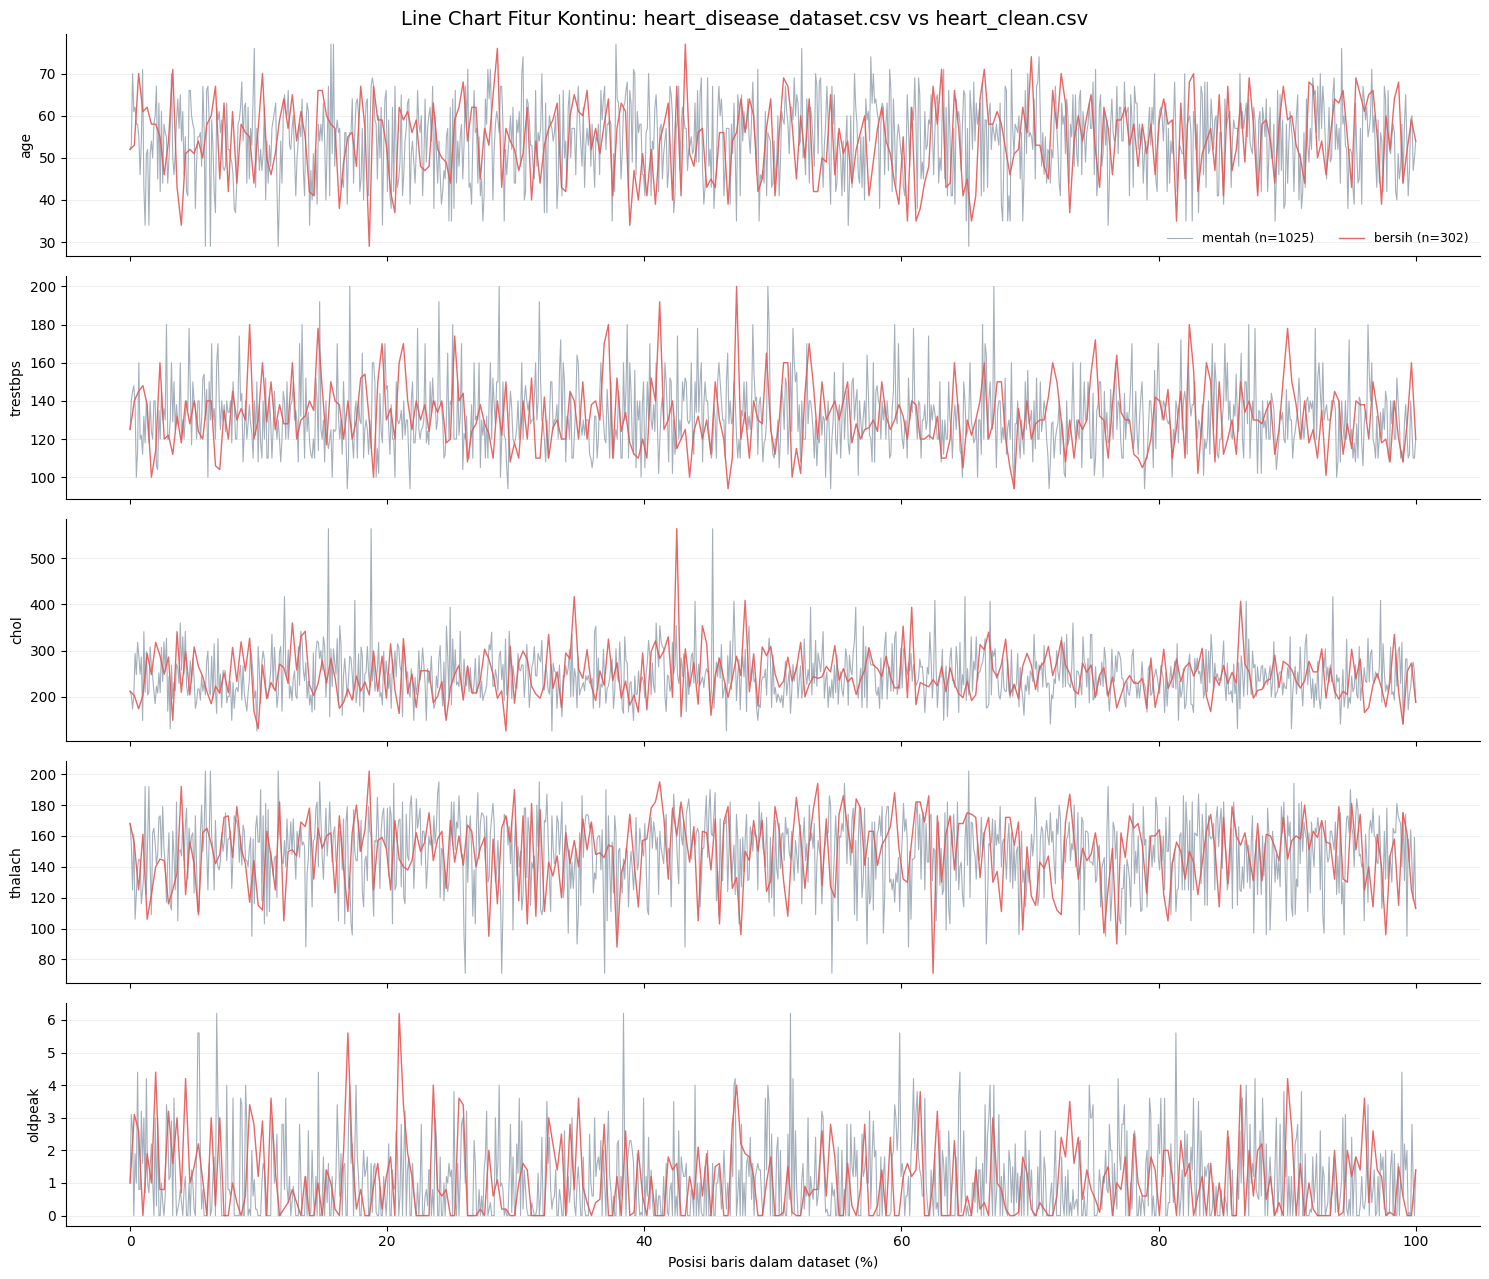

Bacaan: garis merah jauh lebih rapat karena 723 baris duplikat sudah hilang,
tapi rentang naik-turunnya tetap sama - artinya dedup tidak memotong nilai ekstrem,
hanya menghapus pengulangan.


In [116]:
# ---------- muat kedua berkas untuk dibandingkan ----------
mentah = pd.read_csv('heart_disease_dataset.csv')   # 1025 baris, apa adanya
bersih = pd.read_csv('heart_clean.csv')             # hasil STEP 1-8

MENTAH_WARNA, BERSIH_WARNA = '#9AA7B4', '#E45756'
KONTINU = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

print(f'mentah : {mentah.shape}')
print(f'bersih : {bersih.shape}')
print(f'selisih: {len(mentah) - len(bersih)} baris '
      f'({(len(mentah) - len(bersih)) / len(mentah):.1%} dibuang)')

# ---------- LINE CHART: nilai tiap fitur sepanjang dataset ----------
# Jumlah baris berbeda (1025 vs 302), jadi sumbu x dinormalkan ke 0-100%
# supaya kedua garis bisa ditumpuk dan dibandingkan bentuknya.
fig, axes = plt.subplots(len(KONTINU), 1, figsize=(15, 2.6 * len(KONTINU)), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, KONTINU):
    for sumber, warna, lebar, alpha in (
            (mentah, MENTAH_WARNA, 0.8, 0.9),
            (bersih, BERSIH_WARNA, 1.0, 0.9)):
        posisi = np.linspace(0, 100, len(sumber))
        ax.plot(posisi, sumber[col].to_numpy(), color=warna,
                linewidth=lebar, alpha=alpha,
                label=f'{"mentah" if sumber is mentah else "bersih"} (n={len(sumber)})')
    ax.set_ylabel(col)
    ax.grid(axis='y', color='#EEEEEE', linewidth=0.7)
    ax.set_axisbelow(True)
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

axes[0].legend(frameon=False, ncol=2, fontsize=9)
axes[-1].set_xlabel('Posisi baris dalam dataset (%)')
fig.suptitle('Line Chart Fitur Kontinu: heart_disease_dataset.csv vs heart_clean.csv',
             fontsize=14)
plt.tight_layout()
plt.show()

print('Bacaan: garis merah jauh lebih rapat karena 723 baris duplikat sudah hilang,')
print('tapi rentang naik-turunnya tetap sama - artinya dedup tidak memotong nilai ekstrem,')
print('hanya menghapus pengulangan.')

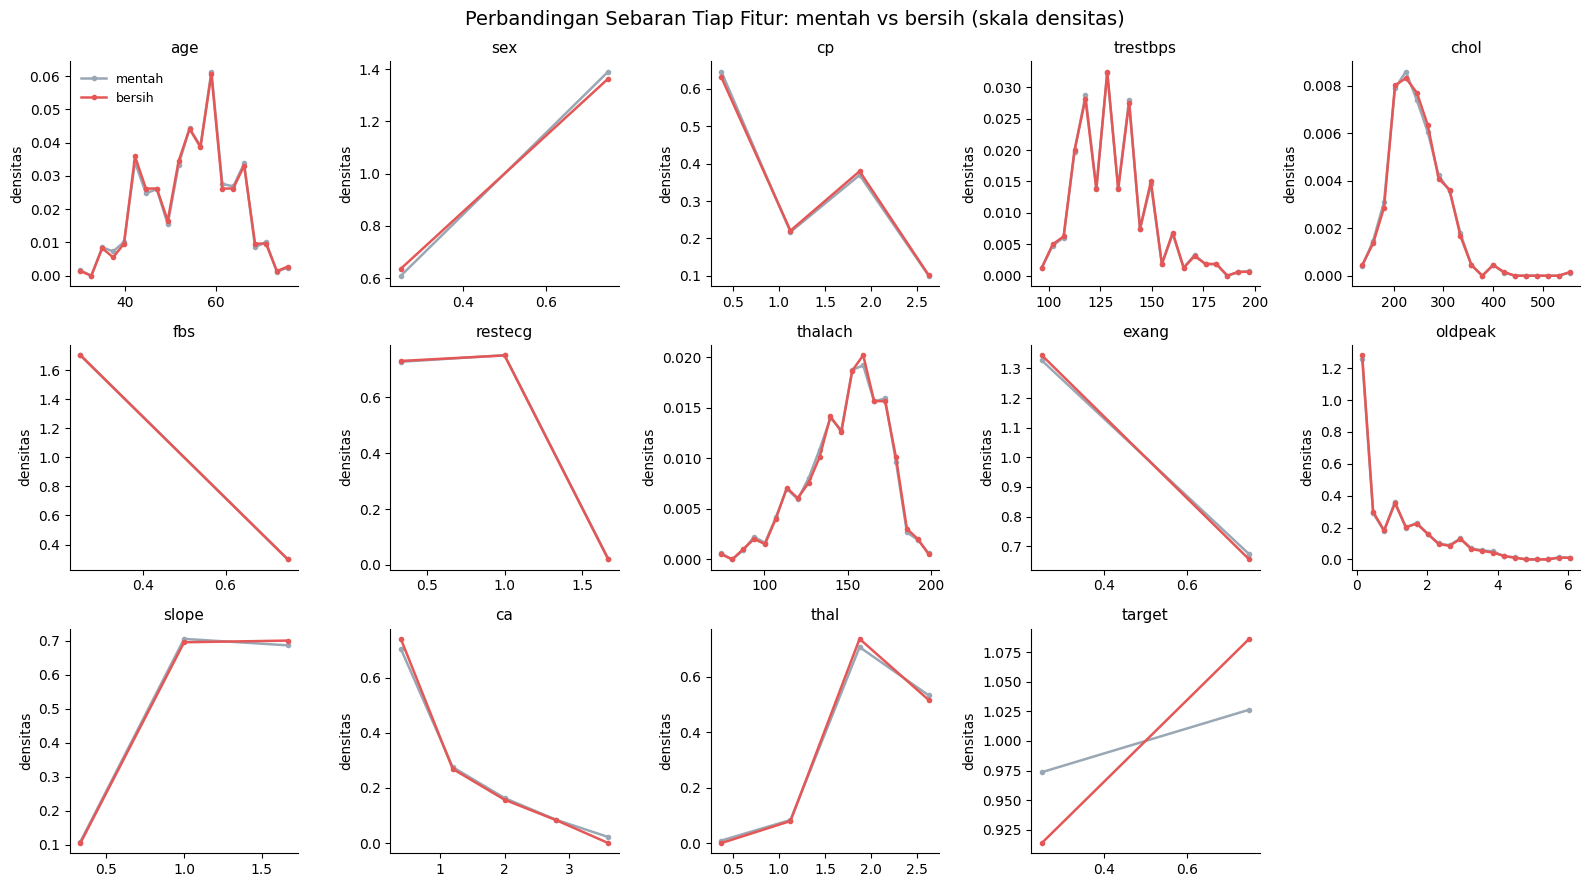

Bacaan: kedua garis nyaris berimpit di semua fitur -> pembersihan TIDAK mengubah
karakter data. Yang berubah jelas hanya ca (nilai 4 hilang) dan thal (nilai 0 hilang).


In [117]:
# ---------- DISTRIBUSI: bentuk sebaran sebelum vs sesudah ----------
# Dinormalkan jadi densitas supaya beda jumlah baris tidak bikin salah baca.
cols = [c for c in bersih.columns]
n, ncols = len(cols), 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, cols):
    tepi = np.histogram_bin_edges(
        np.concatenate([mentah[col], bersih[col]]),
        bins=20 if col in KONTINU else np.unique(mentah[col]).size)
    pusat = (tepi[:-1] + tepi[1:]) / 2
    for sumber, warna, nama in ((mentah, MENTAH_WARNA, 'mentah'),
                                (bersih, BERSIH_WARNA, 'bersih')):
        dens, _ = np.histogram(sumber[col], bins=tepi, density=True)
        ax.plot(pusat, dens, color=warna, linewidth=1.8,
                marker='o', markersize=3, label=nama)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('densitas')
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

for ax in axes[n:]:
    ax.set_visible(False)

axes[0].legend(frameon=False, fontsize=9)
fig.suptitle('Perbandingan Sebaran Tiap Fitur: mentah vs bersih (skala densitas)',
             fontsize=14)
plt.tight_layout()
plt.show()

print('Bacaan: kedua garis nyaris berimpit di semua fitur -> pembersihan TIDAK mengubah')
print('karakter data. Yang berubah jelas hanya ca (nilai 4 hilang) dan thal (nilai 0 hilang).')

=== Pergeseran statistik fitur kontinu ===
          mean_mentah  mean_bersih  std_mentah  std_bersih  geser_mean_%  geser_std_%
age             54.43        54.42        9.07        9.05         -0.03        -0.27
trestbps       131.61       131.60       17.52       17.56         -0.01         0.27
chol           246.00       246.50       51.59       51.75          0.20         0.31
thalach        149.11       149.57       23.01       22.90          0.31        -0.44
oldpeak          1.07         1.04        1.18        1.16         -2.66        -1.16


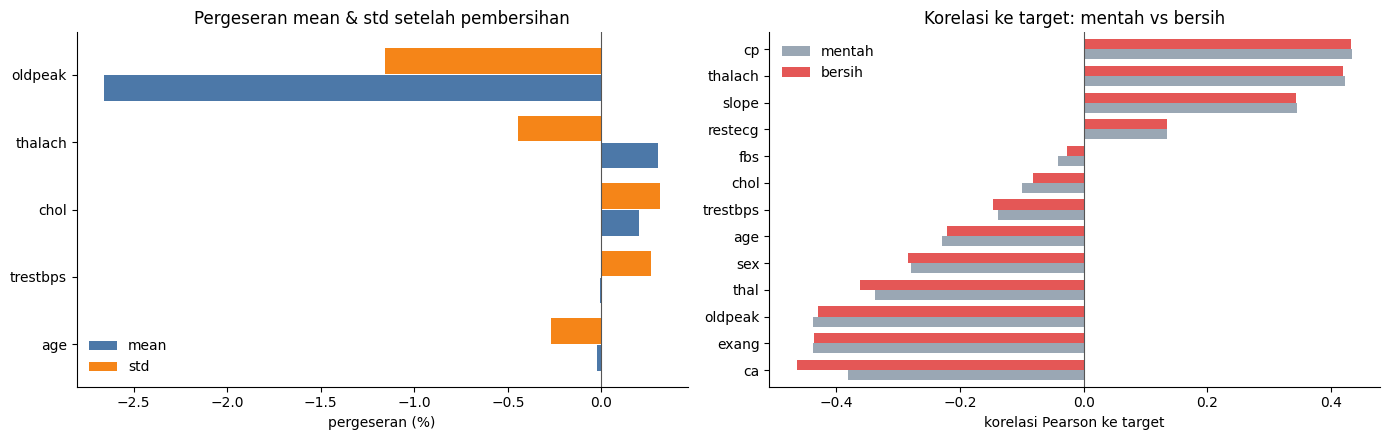


Pergeseran mean terbesar : 2.66%
Pergeseran korelasi terbesar: 0.082


In [118]:
# RINGKASAN ANGKA: 
banding = pd.DataFrame({
    'mean_mentah': mentah[KONTINU].mean(),
    'mean_bersih': bersih[KONTINU].mean(),
    'std_mentah':  mentah[KONTINU].std(),
    'std_bersih':  bersih[KONTINU].std(),
})
banding['geser_mean_%'] = ((banding['mean_bersih'] - banding['mean_mentah'])
                           / banding['mean_mentah'] * 100)
banding['geser_std_%']  = ((banding['std_bersih'] - banding['std_mentah'])
                           / banding['std_mentah'] * 100)

print('=== Pergeseran statistik fitur kontinu ===')
print(banding.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x = np.arange(len(KONTINU))
axes[0].barh(x - 0.2, banding['geser_mean_%'], height=0.38,
             color='#4C78A8', label='mean')
axes[0].barh(x + 0.2, banding['geser_std_%'], height=0.38,
             color='#F58518', label='std')
axes[0].axvline(0, color='#555', linewidth=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(KONTINU)
axes[0].set_xlabel('pergeseran (%)')
axes[0].set_title('Pergeseran mean & std setelah pembersihan')
axes[0].legend(frameon=False)

korelasi = pd.DataFrame({
    'mentah': mentah.corr(numeric_only=True)['target'].drop('target'),
    'bersih': bersih.corr(numeric_only=True)['target'].drop('target'),
}).sort_values('bersih')
korelasi.plot(kind='barh', ax=axes[1], color=[MENTAH_WARNA, BERSIH_WARNA], width=0.75)
axes[1].axvline(0, color='#555', linewidth=0.8)
axes[1].set_xlabel('korelasi Pearson ke target')
axes[1].set_title('Korelasi ke target: mentah vs bersih')
axes[1].legend(frameon=False)

for ax in axes:
    for sisi in ('top', 'right'):
        ax.spines[sisi].set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nPergeseran mean terbesar : {banding["geser_mean_%"].abs().max():.2f}%')
print(f'Pergeseran korelasi terbesar: '
      f'{(korelasi["bersih"] - korelasi["mentah"]).abs().max():.3f}')

### notes further preprocessing

**Apa yang dikerjakan**

1. 723 baris duplikat dihapus, tersisa 302 baris unik.
2. `ca` bernilai 4 dan `thal` bernilai 0 ditandai sebagai missing, lalu diimputasi dengan modus. Hanya 6 baris terdampak.
3. Outlier pada fitur kontinu sengaja dipertahankan karena nilainya valid secara klinis.
4. Tipe tiap fitur ditetapkan eksplisit: kontinu, biner, nominal, ordinal.
5. Asosiasi antar fitur dihitung ulang dengan ukuran yang sesuai tipe masing-masing.
6. Hasil akhir (`heart_clean.csv`) dibandingkan langsung dengan data mentah lewat line chart, kurva sebaran, dan pergeseran statistik.

**Apa yang dipelajari**

1. **Duplikat bukan penyebab korelasi rendah.** Setelah 723 baris dibuang, pergeseran korelasi terbesar cuma 0.027. Jadi angka korelasi yang rendah itu memang sifat datanya.
2. **Membersihkan kode invalid menaikkan sinyal `ca`.** Diukur dari baseline setelah dedup, korelasi `ca` ke target naik dari -0.409 menjadi -0.464 setelah kode 4 dibuang. Nilai 4 yang tidak bermakna itu memang mengaburkan skala ordinalnya.
3. **Pearson meremehkan fitur nominal.** Dengan Cramer's V, `thal` naik dari 0.36 ke 0.52 dan `cp` naik dari 0.43 ke 0.51. Keduanya jadi fitur terkuat, mengalahkan `exang` dan `oldpeak` yang sebelumnya memimpin. Ini koreksi penting terhadap kesimpulan EDA awal.
4. **`fbs` benar-benar tidak berguna.** Cramer's V-nya 0.000 setelah koreksi bias. Ini satu-satunya fitur yang layak dibuang atas dasar data, bukan tebakan.
5. **Tidak ada multikolinearitas.** VIF tertinggi hanya 1.76 pada `oldpeak`. Semua fitur menyumbang informasi sendiri-sendiri, tidak ada yang redundan.
6. **Pasangan fitur paling terkait** adalah `slope` dengan `oldpeak` di angka 0.58. Masuk akal secara medis karena keduanya sama-sama mengukur perilaku segmen ST saat olahraga.
7. **Membuang 70.5% baris hampir tidak menggeser statistik apa pun.** Dari 1025 baris menjadi 302, pergeseran mean fitur kontinu paling besar hanya 2.66% (`oldpeak`); `age`, `trestbps`, dan `chol` bergeser di bawah 0.4%. Pergeseran standar deviasi paling besar 1.2%. Kurva sebaran mentah dan bersih pun nyaris berimpit di semua fitur. Ini bukti kuantitatif bahwa pembersihan menghapus **pengulangan**, bukan mengubah karakter data.

**Catatan tentang dua angka "pergeseran korelasi" yang berbeda**

Angka ini muncul dua kali di notebook dengan nilai berbeda karena diukur pada tahap yang berbeda,
dan keduanya kebetulan terjadi pada fitur yang sama (`ca`):

| Perbandingan | Tahap | Pergeseran terbesar |
|---|---|---|
| sebelum vs sesudah dedup (STEP 1) | dedup saja | 0.027 |
| mentah vs bersih (perbandingan akhir) | dedup + imputasi kode invalid | 0.082 (`ca`: -0.382 -> -0.464) |

Jadi sebagian besar kenaikan sinyal `ca` datang dari pembersihan kode invalid, bukan dari deduplikasi.

**PERINGATAN: arah label `target` patut dicurigai terbalik**

Semua kesimpulan di bawah ditulis dengan asumsi `target` = 1 berarti sakit jantung, mengikuti
nama kolomnya. Tabel korelasi akhir justru menguatkan kecurigaan di bagian *notes: baris mana yang
benar-benar perlu difilter*: `ca` (-0.464), `thal` (-0.362), `exang` (-0.436), dan `oldpeak` (-0.429)
semuanya **negatif** terhadap target, sedangkan `thalach` (+0.420) dan `cp` (+0.432) **positif**.
Secara klinis seharusnya kebalikannya, karena pembuluh tersumbat, defek reversibel, angina saat
olahraga, dan depresi ST adalah penanda penyakit.

Kalau dugaan ini benar, **besaran** di poin 1-7 tetap sah seluruhnya, yang berubah hanya
**arah maknanya**: poin 2, 3, dan 6 harus dibaca terbalik. Konfirmasikan dulu ke berkas UCI asli
(`processed.cleveland.data`) sebelum menulis interpretasi di makalah.

**Konsekuensinya untuk tahap berikutnya**

Karena tidak ada satu pun fitur yang dominan dan tidak ada yang redundan, ini kasus di mana
banyak fitur lemah harus dipakai bersama-sama. Membuang fitur berdasarkan korelasi rendah
justru merugikan, kecuali `fbs` yang memang nol.

Satu catatan praktis: dengan hanya 302 baris unik dari 1025, ukuran sampel efektif jauh lebih kecil
daripada yang terlihat. Pemisahan train/test wajib dilakukan **setelah** deduplikasi, kalau tidak
baris yang sama bisa muncul di kedua sisi dan membuat skor evaluasi tampak jauh lebih baik
daripada kenyataannya.